# Spotify RecSystem End to End (Sistema de Recomendação Spotify de Ponta a Ponta)
**[EN-US]**

Recommendation system, which recommends songs from Spotify. Created end-to-end, i.e. connecting and authorizing with the [Spotify API](https://developer.spotify.com/documentation/web-api), extracting data from the API, performing exploratory analysis, creating the model and producing the model.

**[PT-BR]**

Sistema de recomendação, que recomenda músicas do Spotify. Criado de ponta a ponta, ou seja, a conexão e autorização com a [Spotify API](https://developer.spotify.com/documentation/web-api), extração dos dados da API, realização da anaálise exploratória, criação do modelo e produção do modelo.

## Table of Contents
* [Packages](#1)
* [Environment Variables](#2)
* [Utils Functions](#3)
    * [Ingestion Functions](#3.1)
        * [Request Authorization](#3.1.1)
        * [Playlist Extraction](#3.1.2)
        * [Track Features Extraction](#3.1.3)
        * [Playlist to DataFrame](#3.1.4)
    * [PreProcessing Functions](#3.2)
        * [Get User Dataset](#3.2.1)
    * [Plot Functions](#3.3)
        * [Get Pairs](#3.3.1)
        * [Plot Histogram](#3.3.2)
    * [Model Function](#3.4)
        * [User Neural Network](#3.4.1)
        * [Item Neural Network](#3.4.1)
        * [Model Compile](#3.4.1)
* [Playlist Data Extraction](#4)
    * [Request Authorization](#4.1)
    * [Playlists Definition](#4.2)
    * [Data Extraction and Preparation](#4.3)
* [Exploratory Data Analysis](#5)
    * [PCA](#5.1)
* [Preprocessing](#6)
* [Model](#7)
    * [Content-Based Filtering Algorithm](#7.1)
    * [Content-Based Filtering Model](#7.2)
* [Prediction](#8)
    * [Prediction with Model Only](#8.1)
    * [Cosine Similarity Prediction](#8.2)

<a name="1"></a>
## Packages (Pacotes)
**[EN-US]**

Packages used in the system.
* [os](https://docs.python.org/3/library/os.html): built-in module, provides a portable way of using operating system dependent functionality.
* [requests](https://pypi.org/project/requests/): is a simple HTTP library, for making HTTP requests.
* [base64](https://docs.python.org/pt-br/3.7/library/base64.html): provides functions for encoding binary data to printable ASCII characters and decoding such encodings back to binary data.
* [dotenv](https://pypi.org/project/python-dotenv/): reads key-value pairs from a .env file and can set them as environment variables.
* [pandas](https://pandas.pydata.org/): is the main package for data manipulation.
* [numpy](www.numpy.org): is the main package for scientific computing.
* [tensorflow](https://www.tensorflow.org/): framework that makes it easy to create ML models that can run in any environment.
* [scikit-learn](https://scikit-learn.org/stable/): open source machine learning library.
* [shap](https://shap.readthedocs.io/en/latest/index.html): is a game theoretic approach to explain the output of any machine learning model.
* [matplotlib](http://matplotlib.org): is a library to plot graphs.
* [seaborn](https://seaborn.pydata.org/): data visualization library based on matplotlib.
* [random](https://docs.python.org/pt-br/3/library/random.html): pseudorandom number generator for various distributions.
* [warnings](https://docs.python.org/pt-br/3/library/warnings.html): controls whether warnings are ignored, displayed, or turned into errors (raising an exception).

**[PT-BR]**

Pacotes utilizados no sistema.
* [os](https://docs.python.org/3/library/os.html): módulo integrado, fornece uma maneira portátil de usar funcionalidades dependentes do sistema operacional.
* [requests](https://pypi.org/project/requests/): é uma biblioteca HTTP simples, para fazer solicitações HTTP.
* [base64](https://docs.python.org/pt-br/3.7/library/base64.html): fornece funções para codificar dados binários em caracteres ASCII imprimíveis e decodificar essas codificações de volta para dados binários.
* [dotenv](https://pypi.org/project/python-dotenv/): lê pares de chave-valor de um arquivo .env e pode defini-los como variáveis de ambiente.
* [pandas](https://pandas.pydata.org/): é o principal pacote para manipulação de dados.
* [numpy](www.numpy.org): é o principal pacote para computação científica.
* [tensorflow](https://www.tensorflow.org/): framework que facilita a criação de modelos de machine learning que podem ser executados em qualquer ambiente.
* [scikit-learn](https://scikit-learn.org/stable/): biblioteca open-source de machine learning.
* [shap](https://shap.readthedocs.io/en/latest/index.html): é uma abordagem teórica para explicar o output de qualquer modelo de aprendizado de máquina.
* [matplotlib](http://matplotlib.org): é uma biblioteca para plotar gráficos.
* [seaborn](https://seaborn.pydata.org/): biblioteca de visualização de dados baseada em matplotlib.
* [random](https://docs.python.org/pt-br/3/library/random.html): gerador de números pseudoaleatórios para várias distribuições.
* [warnings](https://docs.python.org/pt-br/3/library/warnings.html): controla se os avisos são ignorados, exibidos ou transformados em erros (gerando uma exceção).

In [5]:
import os
from requests import post, get
from base64 import b64encode
from dotenv import load_dotenv
load_dotenv() # access environment variables (acessa as variáveis de ambiente)

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, BatchNormalization, Input, Dot, Dropout, Layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.activations import sigmoid
from tensorflow.keras import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
import shap

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 15) # set default size of plots (definindo o tamanho padrão dos plots)
import seaborn as sns
from random import randint

from warnings import simplefilter
simplefilter('ignore')

C:\Users\guine\AppData\Local\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Checking tensorflow version (Verificando a versão do tensorflow).

In [7]:
tf.__version__

'2.18.0'

<a name="2"></a>
## Environment Variables (Variáveis de Ambiente)
**[EN-US]**

Setting the environment variables:
* `CLIENT_ID`: the client ID generated after registering your application.
* `CLIENT_SECRET`: the client secret generated after registering your application.

**[PT-BR]**

Definindo as variáveis de ambiente:
* `CLIENT_ID`: o cliente ID gerado após registrar seu aplicativo.
* `CLIENT_SECRET`: o client secret gerado após o registro do seu aplicativo.

In [9]:
CLIENT_ID = os.environ['CLIENT_ID_SPOTIFY']
CLIENT_SECRET = os.environ['CLIENT_SECRET_SPOTIFY']

<a name="3"></a>
## Utils Functions (Funções Utilitárias)
**[EN-US]**

Various useful functions used in this system.

**[PT-BR]**

Várias funções utilitárias utilizadas nesse sistema.

<a name="3.1"></a>
### Ingestion Functions (Funções de Ingestão)
<img align='center' src='./images/auth-client-credentials.png' style='width:800px;'>

**[EN-US]**

Utility functions for ingestion. `request_auth` function to request authorization from Spotify, `get_playlist` function to extract the tracks from a playlist and the `track_features` function to extract the features of these tracks. After that, the `playlist_to_dataframe` function transforms the data in JSON to a pandas DataFrame.

**[PT-BR]**

Funções utilitárias para a ingestão. Função `request_auth` para requisitar a autorização ao spotify, função `get_playlist` para extrair as tracks de uma playlist e a função `track_features` para extrair as features dessas tracks. Após isso, a função `playlist_to_dataframe` transforma os dados em JSON para um DataFrame pandas.

<a name="3.1.1"></a>
#### Request Authorization (Requisitando a Autorização)
**[EN-US]**

The first step is to send a POST request to the `/api/token` endpoint of the Spotify OAuth 2.0 Service. If everything goes well, you'll receive a response with a 200 OK status and the JSON data.

**[PT-BR]**

A primeira etapa é enviar uma requisição POST para o endpoint `/api/token` do serviço Spotify OAuth 2.0. Se tudo correr bem, você receberá uma resposta com o status 200 OK e os dados JSON.

In [13]:
def request_auth(client_id, client_secret):
    """
    [EN-US]
    The first step is to send a POST request to the /api/token endpoint of the Spotify OAuth 2.0 Service.
    If everything goes well, you'll receive a response with a 200 OK status and the JSON data.
    
    [PT-BR]
    A primeira etapa é enviar uma requisição POST para o endpoint /api/token do serviço Spotify OAuth 2.0.
    Se tudo correr bem, você receberá uma resposta com o status 200 OK e os dados JSON.
    
    Arguments:
        client_id -- The client ID generated after registering your application
                     (O cliente ID gerado após registrar seu aplicativo).
        client_secret -- the client secret generated after registering your application
                         (O client secret gerado após o registro do seu aplicativo).
        
    Returns:
        access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services
                        (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API).
        token_type -- How the access token may be used: always "Bearer"
                      (Como o token de acesso pode ser utilizado: sempre “Bearer”).
        token_expires -- The time period (in seconds) for which the access token is valid
                         (O período de tempo (em segundos) durante o qual o token de acesso é válido).
    """
    # Base 64 encoded string that contains the client ID and client secret key (String codificada em base 64 que contém o clinet ID e a client secret key)
    b64_encoded = b64encode(f'{client_id}:{client_secret}'.encode())
    auth_b64 = str(b64_encoded, 'utf-8')
    # Setting options for authorization (Definindo as opções para a autorização)
    base_url = 'https://accounts.spotify.com/api/token'    
    
    auth_options = {
        'url': base_url,
        'headers':{
            'Authorization': 'Basic ' + auth_b64,
            'content-type': 'application/x-www-form-urlencoded'
        },
        'form':{
            'grant_type': 'client_credentials'
        },
        'json': True
    }

    # Send a post request (Enviando a requisição post)
    request = post(url=auth_options['url'], headers=auth_options['headers'], data=auth_options['form'])
    # If the request status code is 200 (Caso o status code da requisição for 200)
    if request.status_code == 200:
        json_request = request.json()
        access_token = json_request['access_token']
        token_type = json_request['token_type']
        token_expires = json_request['expires_in']
        print('Acesso autorizado e dados extraídos!')
    else:
        print('Acesso não autorizado!')
        
    return access_token, token_type, token_expires

<a name="3.1.2"></a>
#### Playlist Extraction (Extração da Playlist)
**[EN-US]**

Get full details of the items of a playlist owned by a Spotify user.

**[PT-BR]**

Obtenha detalhes completos dos itens de uma playlist de um usuário do Spotify.

In [15]:
def get_playlist(playlist, token_type, access_token, offset=0, limit=100):
    """
    [EN-US]
    Get full details of the items of a playlist owned by a Spotify user.
    
    [PT-BR]
    Obtenha detalhes completos dos itens de uma playlist de propriedade de um usuário do Spotify.
    
    Arguments:
        playlist -- The Spotify URL of the playlist
                    (O URL do Spotify da playlist).
        token_type -- How the access token may be used: always "Bearer"
                      (Como o token de acesso pode ser utilizado: sempre “Bearer”).
        access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services
                        (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API).
        offset -- The index of the first item to return. Default: 0 (the first item). Use with limit to get the next set of items
                  (O índice do primeiro item a ser retornado. Padrão: 0 (o primeiro item). Use com limit para obter o próximo conjunto de itens).
        limit -- The maximum number of items to return. Default: 100. Minimum: 1. Maximum: 100
                 (O número máximo de itens a serem retornados. Padrão: 100. Mínimo: 1. Máximo: 100).
    
    Returns:
        response.json() -- Pages of tracks in JSON (Páginas de tracks em JSON).
    """
    # Turning the Spotify playlist URL into just the Playlist ID to send the get request (Transformando o Spotify URL da playlist apenas no Playlist ID para enviar a requisição get)
    playlist_id = playlist.split('/')[-1].split('?')[0]
    # Setting options for the request (Definindo as opções para a requisição)
    endpoint = f'https://api.spotify.com/v1/playlists/{playlist_id}/tracks?offset={str(offset)}&limit={str(limit)}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }

    # Send a get request (Enviando a requisição get)
    response = get(url=endpoint, headers=headers)
    # If the request status code is not 200 (Caso o status code da requisição não seja 200)
    if response.status_code != 200:
        print('Error! Dados da playlist não extraídos.')

    return response.json()

<a name="3.1.3"></a>
#### Track Features Extraction (Extração das Features da Track)
<img align='center' src='./images/track-features.png' style='width:800px;'>

**[EN-US]**

Get audio feature information for a single track identified by its unique Spotify ID.

**[PT-BR]**

Obtenha informações sobre features de áudio de uma única faixa identificada por seu ID exclusivo do Spotify.

In [17]:
def track_features(track_id, token_type, access_token):
    """
    Deprecated
    [EN-US]
    Get audio feature information for a single track identified by its unique Spotify ID.
    
    [PT-BR]
    Obtenha informações sobre features de áudio de uma única faixa identificada por seu ID exclusivo do Spotify.
    
    Arguments:
        track_id -- The Spotify ID for the track (O ID do Spotify para a track).
        token_type -- How the access token may be used: always "Bearer"
                      (Como o token de acesso pode ser utilizado: sempre “Bearer”).
        access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services
                        (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API).
    
    Returns:
        response.json() -- Audio features for one track in JSON
                           (Features de áudio para uma track em JSON).
    """
    # Setting options for the request (Definindo as opções para a requisição)
    endpoint = f'https://api.spotify.com/v1/audio-features/{track_id}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }
    
    # Send a get request (Enviando a requisição get)
    response = get(url=endpoint, headers=headers)
    # If the request status code is not 200 (Caso o status code da requisição não seja 200)
    if response.status_code != 200:
        print('Error! Dados da track não extraídos.')

    return response.json()

<a name="3.1.4"></a>
#### Playlist to DataFrame (Playlist para DataFrame)
**[EN-US]**

Input's a playlist URL and returns a pandas DataFrame.

**[PT-BR]**

A entrada é um URL de uma playlist e retorna um DataFrame do pandas.

In [19]:
def playlist_to_dataframe(playlist_endpoint, token_type, access_token, offset=0, limit=100, label=None):
    """
    [EN-US]
    Input's a playlist URL and returns a pandas DataFrame.
    
    [PT-BR]
    A entrada é um URL de uma playlist e retorna um DataFrame do pandas.
    
    Arguments:
        playlist_endpoint -- The Spotify URL of the playlist (O URL do Spotify da playlist).
        token_type -- How the access token may be used: always "Bearer"
                      (Como o token de acesso pode ser utilizado: sempre “Bearer”).
        access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services
                        (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API).
        offset -- The index of the first item to return. Default: 0 (the first item). Use with limit to get the next set of items
                  (O índice do primeiro item a ser retornado. Padrão: 0 (o primeiro item). Use com limit para obter o próximo conjunto de itens).
        limit -- The maximum number of items to return. Default: 100. Minimum: 1. Maximum: 100
                 (O número máximo de itens a serem retornados. Padrão: 100. Mínimo: 1. Máximo: 100).
        label -- The label that the playlist will be classified by. Default: None. Label 1 for good playlist and 0 for bad playlist
                 (O label que a playlist será classificada. Padrão: None. Label 1 para playlist boa e 0 para playlist ruim).
        
    Returns:
        df -- Pandas DataFrame with all tracks and the features of each track in the playlist
              (DataFrame pandas com todas as tracks e as features de cada track da playlist).
    """
    # Final list that will be transformed into DataFrame (Lista final que será transformada em DataFrame)
    examples = []
    # Tracks in JSON (Tracks em JSON)
    playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=offset, limit=limit)
    
    # For loop through all playlist pages (Percorrendo todas as páginas da playlist)
    for page in range(offset, playlist['total'] + 1, limit):
        # Example size on page (Tamanho de exemplo na página)
        m = len(playlist['items'])
        # For loop through each example and adding the data to the final list (Percorrendo cada exemplo e adicionando os dados à lista final)
        for i in range(m):
            # Accessing each track (Acessando cada track)
            track = playlist['items'][i]['track']
            # Track features in JSON (Features da track em JSON)
            track_feature = track_features(track['id'], token_type, access_token)


            # Intermediate list for append each m example (Lista intermediária para adicionar cada exemplo m)
            example = [
                track['id'],
                track['name'],
                track['artists'][0]['name'],
                track['duration_ms'],
                track['popularity'],
                track_feature['danceability'],
                track_feature['energy'],
                track_feature['key'],
                track_feature['loudness'],
                track_feature['mode'],
                track_feature['speechiness'],
                track_feature['acousticness'],
                track_feature['instrumentalness'],
                track_feature['liveness'],
                track_feature['valence'],
                track_feature['tempo']
            ]

            # Adding to final list (Adicionando à lista final)
            examples.append(example)
        # If the page has more than 100 examples, you will read the next page
        # (Se a página tiver mais de 100 exemplos, lerá a próxima página)
        if m >= 100:
            # JSON tracks of the next offset (Tracks em JSON do próximo offset)
            playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=page + limit, limit=limit)
    
    # DataFrame's features names (Nomes das features do DataFrame)
    features = ['id', 'name', 'artists', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
               'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
    # Transforming into DataFrame (Transformando em DataFrame)
    df = pd.DataFrame(examples, columns=features)
    
    # Setting the labels (Definindo os labels)
    if label == 0:
        df['y'] = 0
    elif label == 1:
        df['y'] = 1
    
    return df

<a name="3.2"></a>
### PreProcessing Functions (Funções de Pré-Processamento)
**[EN-US]**

Utility functions for preprocessing. The `get_user_dataset` function returns the user's dataset. Given a vector with the desired features, the function returns a dataset with these features copied across all examples, the number of examples is calculated over the number of examples in the dataset passed as reference.

**[PT-BR]**

Funções utilitárias para o pré-processamento. A função `get_user_dataset` retorna o dataset do usuário. Dado um vetor com as features desejadas, a função retorna um dataset com essas features copiadas em todos os exemplos, o número de exemplos é calculado sobre o número de exemplos do dataset passado como referência.

<a name="3.2.1"></a>
#### Get User Dataset (Cria o Dataset do Usuário)
**[EN-US]**

Creates the user's dataset with the same number of examples as the dataset passed as input.

**[PT-BR]**

Cria o dataset do usuário com a mesma quantidade de exemplos que o dataset passado como input.

In [22]:
def get_user_dataset(user_vec, item_df):
    """
    [EN-US]
    Creates the User Dataset with the same number of examples as the dataset that was given as reference.
    
    [PT-BR]
    Cria o Dataset do usuário com a mesma quantidade de exemplos do que o dataset que foi dado como referência.
    
    Argument:
        user_vec -- Row vector with user features
                    (Vetor de linha com as features do usuário).
        item_df -- Reference Dataset to create User Dataset
                   (Dataset de referência para criar o Dataset do usuário).
    
    Return:
        user_df -- User dataset with the same dimensions as the reference dataset
                   (Dataset do usuário com as mesmas dimensões do dataset de referência).
    """
    # Creating the user matrix (Criando a matriz do usuário).
    user_df = np.tile(user_vec, (len(item_df), 1))
    features = list(item_df.columns)
    
    # Transforming the numpy array into a pandas DataFrame (Transformando o array numpy em um DataFrame pandas).
    user_df = pd.DataFrame(user_df, columns=features)
    return user_df

<a name="3.2.2"></a>
#### $L_2$ Norm Layer (Layer da Norma $L_2$)
**[EN-US]**

Creates the `tf.keras.Layer` object that transforms the calculation of the $L_2$ norm into a layer for us to add to the model.

**[PT-BR]**

Cria o objeto `tf.keras.Layer` que transforma o cálculo da norma $L_2$ em uma layer para adicionarmos ao modelo.

In [24]:
class L2_Norm(tf.keras.Layer):
    """
    [EN-US]
    Transforms the L2 norm computation into a layer.

    [PT-BR]
    Transforma o cálculo da nomra L2 em uma layer.
    """
    def call(self, X):
        """
        [EN-US]
        Computes the L2 norm in the matrix.
    
        [PT-BR]
        Calcula a norma L2 na matriz X.
        
        Argument:
            X -- X matrix (Matriz X).
        
        Return:
            tf.linalg.l2_normalize -- The L2 norm that will be calculated in the layer.
                                      (A nroma L2 que será calculada na layer.)
        """
        # Returning the calculation that will be performed (Retornando o cálculo que será realizado).
        return tf.linalg.l2_normalize(X, axis=1)

<a name="3.3"></a>
### Plot Functions (Funções de Gráficos)
**[EN-US]**

Utility functions for plots. The `get_pairs` function returns 25 random unique pairs of features, `plot_hist_vs` plots a histogram comparing 2 labels from a dataset with numeric features, `plot_loss` plots the evaluation metric and the loss during model training.

**[PT-BR]**

Funções utilitárias para os plots. A função `get_pairs` retorna 25 pareas únicos aleatórios de features, `plot_hist_vs` plota um histograma comparando 2 labels de um dataset com features numéricas, `plot_loss` plota a métrica de avaliação e a loss durante o treinamento do modelo.

<a name="3.3.1"></a>
#### Get Pairs (Pega os Pares)
**[EN-US]**

Randomly returns 25 unique pairs of features.

**[PT-BR]**

Retorna aleatoriamente 25 pares únicos de features.

In [27]:
def get_pairs(df):
    """
    [EN-US]
    The input is a DataFrame and returns a list of unique pairs of features from that DataFrame.
    
    [PT-BR]
    A entrada é um DataFrame e retorna uma lista com pares únicos de features desse DataFrame.
    
    Argument:
        df -- DataFrame to randomly get 25 unique pairs of your features
              (DataFrame para pegar aleatóriamente 25 pares únicos de suas features).
    
    Returns:
        pairs -- List with unique pairs of DataFrame features
                 (Lista com pares únicos de features do DataFrame).
    """
    # Empty list to store tuples with pairs (Lista vazia para armazenar os as tuplas com os pares).
    pairs = []

    for i in range(25):
        # Selecting the first feature (Selecionando a primeira feature).
        x = df.columns[randint(0,12)]
        # Selecting the second feature (Selecionando a segunda feature).
        y = df.columns[randint(0,12)]
        # Loop to not select the 2nd feature repeated or equal to the first feature
        # (Loop para não selecionar a 2 feature repetida ou igual a primeira feature).
        while x == y or (x, y) in pairs or (y, x) in pairs:
            y = df.columns[randint(0,12)]
        pairs.append((x, y))
    
    return pairs

<a name="3.3.2"></a>
#### Plot Histogram (Plota Histograma)
**[EN-US]**

Returns a histogram comparing a feature between 2 labels.

**[PT-BR]**

Retorna um histograma comparando uma feature entre 2 classes.

In [29]:
def plot_hist_vs(X):
    """
    [EN-US]
    Returns a histogram comparing the distribution of numeric features between the positive and negative class.
    
    [PT-BR]
    Retorna um histograma comparando a distribuição das features numéricas entre a classe positiva e negativa.
    
    Arguments:
        X -- X matrix (Matriz X).
    """
    # Excluding categorical features (Excluindo as features categóricas).
    X = X.drop(columns=['name', 'artists', 'duration_ms', 'mode']).copy()
    # Selecting the positive class (Selecionando a classe positiva).
    label_1 = X[X['y'] == 1].drop(columns=['y']).copy()
    # Selecting the negative class (Selecionando a classe negativa).
    label_0 = X[X['y'] == 0].drop(columns=['y']).copy()

    # Creating the figure for the plot (Criando a figura para o plot).
    fig, axs = plt.subplots(4, 3, figsize=(12, 6))
    i = 0

    # Going through each line of the axis (Percorrendo cada linha do eixo).
    for rows in axs:
        # Going through each element of the line (Percorrendo cada elemento da linha),
        for ax in rows:
            # Creating the plot for each feature (Criando o plot para cada feature).
            title = label_1.columns[i].capitalize()
            ax.hist(label_1[label_1.columns[i]].to_list(), bins=100, color='b', label='Good')
            ax.hist(label_0[label_0.columns[i]].to_list(), bins=100, color='r', alpha=0.7, label='Bad')
            ax.set_title(title)
            i += 1
            if i == 12:
                break
    plt.legend(loc='best')
    plt.show()

<a name="3.3.3"></a>
#### Plot Loss (Plota Loss)
**[EN-US]**

Returns a plot with the metric and loss of the model during the training epochs.

**[PT-BR]**

Retorna um plot com a métrica e o loss do modelo durante as epochs de treinamento.

In [31]:
def plot_loss(history):
    """
    [EN-US]
    Plots the model's training loss history per epoch.
    
    [PT-BR]
    Plota o histórico da loss do treinamento do model por epocho.

    Arguments:
        history -- history returned by model training (histórico retornado pelo treino do modelo).
    """
    # Accessing the vector with the history of each metric (Acessando o vetor com o histórico de cada métrica).
    loss = history.history['loss']
    # Selecting the number of epochs (Selecionando a quantidade de epochs).
    epochs = range(len(loss))

    # Defining the figure and creating the plots (Definindo a figura e criando os plots).
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle('Loss History per Epoch')
    # Plotting with all epochs (Plotando com todas as epochs).
    ax[0].plot(epochs, loss, color='g')
    ax[0].set_ylabel('loss')
    ax[0].set_xlabel('epochs')

    # Plotting only the final 25% of the epoch (PLotando apenas os 25% final da epoch). 
    ax[1].plot(epochs, loss, color='g')
    ax[1].set_xlim(int((len(loss) * .75)), len(loss))
    ax[1].set_xlabel('epochs')
    plt.show()

<a name="3.4"></a>
### Model Functions (Funções do Modelo)
**[EN-US]**

Utility functions for creating neural networks, defining and defining error metrics, optimizing and evaluating the model. The `user_nn` function creates the user neural network, `item_nn` creates the item neural network, and `compile_model` compiles and defines the complete model, computing the dot product between the user and item neural networks.

**[PT-BR]**

Funções utilitárias para a criação das redes neurais, definição e definição das métricas de erro, otimização e avaliação do modelo. A função `user_nn` cria a rede neural do usuário, `item_nn` cria a rede neural do item, e `compile_model` compila e define o modelo completo, computando o dot product entre a rede neural do usuário e do item.

<a name="3.4.1"></a>
#### User Neural Network (Rede Neural do Usuário)
**[EN-US]**

Utility function for creating the user's neural network.

**[PT-BR]**

Função utilitária para a criação da rede neural do usuário.

In [34]:
def user_nn(units=[256, 128, 64], num_outputs=32, lambda_r=1e-3):
    """
    [EN-US]
    Creates the user's neural network.
    
    [PT-BR]
    Cria a rede neural do usuário.
    
    Arguments:
        units -- Vector with the number of neurons in each layer, there are 3 hidden dense layers in total
                 (Vetor com a quantidade de neurônios em cada layers, são 3 camadas densas ocultas no total).
        num_outputs -- Number of units in the output layer (Número de neurônios da output layer).
        lambda_r -- Value of the layer regularization hyperparameter, lambda
                    (Valor do hiperparâmetro de regularização da layer, lambda).

    Returns:
        user_NN -- User neural network (Rede neural do usuário).
    """
    # Defining the user's neural network, with 3 dense hidden layers, and 1 output dense layer. Between them we are calculating the batch norm, with the BatchNormalization() layer
    # Definindo a rede neural do usuário, com 3 dense hidden layers, e 1 output dense layer. Entre elas estamos calculando a batch norm, com a layer BatchNormalization()
    user_NN = Sequential([
        Dense(units=units[0], activation='relu', kernel_regularizer=l2(lambda_r), name='user_l1'),
        BatchNormalization(),
        Dense(units=units[1], activation='relu', kernel_regularizer=l2(lambda_r), name='user_l2'),
        BatchNormalization(),
        Dense(units=units[2], activation='relu', kernel_regularizer=l2(lambda_r), name='user_l3'),
        BatchNormalization(),
        Dense(units=num_outputs, activation='linear', name='user_output')
    ], name='user_NN')
    return user_NN

<a name="3.4.2"></a>
#### Item Neural Network (Rede Neural do Item)
**[EN-US]**

Utility function for creating the item's neural network.

**[PT-BR]**

Função utilitária para a criação da rede neural do item.

In [36]:
def item_nn(units=[256, 128, 64], num_outputs=32, lambda_r=1e-3):
    """
    [EN-US]
    Creates the item's neural network.
    
    [PT-BR]
    Cria a rede neural do item.
    
    Arguments:
        units -- Vector with the number of neurons in each layer, there are 3 hidden dense layers in total
                 (Vetor com a quantidade de neurônios em cada layers, são 3 camadas densas ocultas no total).
        num_outputs -- Number of units in the output layer (Número de neurônios da output layer).
        lambda_r -- Value of the layer regularization hyperparameter, lambda
                    (Valor do hiperparâmetro de regularização da layer, lambda).

    Returns:
        item_NN -- Item neural network (Rede neural do item).
    """
    # Defining the item's neural network, with 3 dense hidden layers, and 1 output dense layer. Between them we are calculating the batch norm, with the BatchNormalization() layer
    # Definindo a rede neural do item, com 3 dense hidden layers, e 1 output dense layer. Entre elas estamos calculando a batch norm, com a layer BatchNormalization()
    item_NN = Sequential([
        Dense(units=units[0], activation='relu', kernel_regularizer=l2(lambda_r), name='item_l1'),
        BatchNormalization(),
        Dense(units=units[1], activation='relu', kernel_regularizer=l2(lambda_r), name='item_l2'),
        BatchNormalization(),
        Dense(units=units[2], activation='relu', kernel_regularizer=l2(lambda_r), name='item_l3'),
        BatchNormalization(),
        Dense(units=num_outputs, activation='linear', name='item_output')
    ], name='item_NN')
    return item_NN

<a name="3.4.3"></a>
#### Model Compile (Compilação do Modelo)
**[EN-US]**

Utility function to compile the model, using the cost function and the chosen optimization metric, and using the `AUC_ROC` metric to evaluate the predictions.

**[PT-BR]**

Função utilitária para compilar o modelo, utilizando a função de custo e a métrica de otimização escolhida, e utilizando a métrica `AUC_ROC` para avaliação das previsões.

In [38]:
def model_compile(
    optimizer,
    loss, 
    num_user_features, 
    num_item_features,
    item_similarity=False,
    user_units=[256, 126, 64],
    item_units=[256, 126, 64],
    num_outputs=32,
    lambda_r=1e-3
):
    """
    [EN-US]
    Compiles the model.
    
    [PT-BR]
    Compila o modelo.

    Arguments:
        optimizer -- optimizers metrics (Métrica de otimização).
        loss -- Loss function (Função de perca).
        num_user_features -- Number of features in the user dataset (Número de features do dataset do usuário).
        num_item_features -- Number of features in the item dataset (Número de features do dataset do item).
        item_similarity -- If set to True, it will compile only the item's neural network for similarity calculation, otherwise it will compile the complete network.
                           (Se for definida como True, compilará apenas a rede neural do item para o calculo da similaridade, caso contrário, compilará a rede completa).
        user_units -- Vector with the number of neurons in each layer for the user net, there are 3 hidden dense layers in total
                      (Vetor com a quantidade de neurônios em cada layers para a rede do usuário, são 3 camadas densas ocultas no total).
        item_units -- Vector with the number of neurons in each layer for the item net, there are 3 hidden dense layers in total
                      (Vetor com a quantidade de neurônios em cada layers para a rede do item, são 3 camadas densas ocultas no total).
        num_outputs -- Number of units in the output layer (Número de neurônios da output layer).
        lambda_r -- Value of the layer regularization hyperparameter, lambda
                    (Valor do hiperparâmetro de regularização da layer, lambda).

    Returns:
        model -- Compiled model (Modelo compilado).
    """
    # Setting the user and item neural network (Definindo a rede neural do usuário e do item)
    user_NN = user_nn(
        user_units,
        num_outputs,
        lambda_r
    )
    item_NN = item_nn(
        item_units,
        num_outputs,
        lambda_r
    )
    
    # Setting the user network input shape
    # Definindo o input shape da rede do usuário
    input_user = Input(shape=(num_user_features,))
    # The user network will receive the output from the Input layer
    # A rede do usuário receberá o output da Input layer
    vu = user_NN(input_user)
    # The l2 norm layer will receive the output from the user network
    # A layer da norma l2 receberá o output da rede do usuário
    vu = L2_Norm()(vu)

    # Setting the item network input shape
    # Definindo o input shape da rede do item
    input_item = Input(shape=(num_item_features,))
    # The item network will receive the output from the Input layer
    # A rede do item receberá o output da Input layer
    vr = item_NN(input_item)
    # The l2 norm layer will receive the output from the item network
    # A layer da norma l2 receberá o output da rede do item
    vr = L2_Norm()(vr)

    # Computing the dot product between the user vector vu and the item vector vi
    # Calculando o dot product entre o vetor do usuário vu e o vetor de itens vi
    dot_product = Dot(axes=1)([vu, vr])

    # Computing the sigmoid function on the dot product output
    # Calculando a função sigmoide sobre o output do dot product
    output = sigmoid(dot_product)

    # Defining the model depending on the parameter value
    # Definindo o modelo dependendo do valor do parâmetro
    if item_similarity:
        # Model with only the item network (Modelo apenas com a rede do item)
        model = Model(input_item, vr)
    else:
        # Complete model, with user and item network (Modelo completo, com a rede do usuário e do item)
        model = Model([input_user, input_item], output)

    # Setting the optimizer and the loss function for the model
    # Definindo o otimizador e a função de perda para o modelo
    opt = optimizer
    cost = loss
    # Compiling the model (Compilando o modelo)
    model.compile(loss=loss, optimizer=opt, metrics=['auc'])

    return model

<a name="4"></a>
## Playlist Data Extraction (Extração dos Dados da Playlist)
**[EN-US]**

Extraction, transformation and loading (ETL) of data.

**[PT-BR]**

Extração, transformação e carregamento (ETL) dos dados.

<a name="4.1"></a>
### Request Authorization (Solicitar Autorização)
Requesting Spotify Authorization (Solicitando a autorização do Spotify).

In [41]:
access_token, token_type, token_expires = request_auth(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)

Acesso autorizado e dados extraídos!


<a name="4.2"></a>
### Playlists Definition (Definição das Playlists)
Setting the playlists to be extracted (Definindo as playlists que serão extraidas).

In [43]:
good_songs = 'https://open.spotify.com/playlist/6DI0NiX9bE3fIF6cEoI2zL?si=ef8a610d53f64627'
good_songs_2 = 'https://open.spotify.com/playlist/08bsg8CsImua5vzGMoiGLT?si=7ea323f1c8404b0b'
bad_songs = 'https://open.spotify.com/playlist/6IBody2iNg5TgmAeYiHYpW?si=xsEvNjbbQYqt0rs9wP3yOg'

<a name="4.3"></a>
### Data ETL. Extraction, Transform and Load (Extração, Transformação e Carregamento dos Dados)
Extracting the data from the playlist and projecting the first 5 examples from the `df_good` playlist dataset (Extraindo os dados da plalist e projetando os 5 primeiros exemplos do dataset da playlist `df_good`).

In [45]:
#df_good = playlist_to_dataframe(good_songs, token_type, access_token, offset=0, limit=100, label=1)
#df_good_2 = playlist_to_dataframe(good_songs_2, token_type, access_token, offset=0, limit=100, label=1)
#df_bad = playlist_to_dataframe(bad_songs, token_type, access_token, offset=0, limit=100, label=0).drop(columns=['name'])
#df_good_2.head()

Creating the `duration_min` feature (Criando a feature `duration_min`).

In [47]:
#df_good['duration_min'] = df_good['duration_ms'] / 60000
#df_good_2['duration_min'] = df_good_2['duration_ms'] / 60000
#df_bad['duration_min'] = df_bad['duration_ms'] / 60000

#df_good.head()

Loading each dataset into the `./data/` directory (Carregando cada dataset no diretório `./data/`).

In [49]:
#df_good.to_csv('./data/df_good.csv', index=False)
#df_good_2.to_csv('./data/df_good_2.csv', index=False)
#df_bad.to_csv('./data/df_bad.csv', index=False)

<a name="5"></a>
## Exploratory Data Analysis (EDA)
**[EN-US]**

Exploratory Data Analysis.

Input $X$ features:
* `id`: the Spotify ID for the track.
* `name`: the name of the track.
* `artists`: the principal artist who performed the track.
* `duration_ms`: the track length in milliseconds.
* `popularity`: a measure from 0 to 100 describing the popularity of the track.
* `danceability`: a measure from 0.0 to 1.0 describing how suitable a track is for dancing.
* `energy`: a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity.
* `key`: the key the track is in. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1.
* `loudness`: the overall loudness of a track in decibels (dB). Values typically range between -60 and 0 db.
* `mode`: indicates the modality, major "1" or minor "0", of a track.
* `speechiness`: a measure from 0.0 to 1.0 detecting the presence of spoken words in a track.
* `acousticness`: a confidence measure from 0.0 to 1.0 of whether the track is acoustic.
* `instrumentalness`: a measure from 0.0 to 1.0 predicting whether a track contains no vocals.
* `liveness`: a mearure from 0.0 to 1.0 detecting the presence of an audience in the recording.
* `valence`: a measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track.
* `tempo`: the overall estimated tempo of a track in beats per minute (BPM).
* `y`: the track's label, 1 for good and 0 otherwise.
* `duration_min`: the track length in minutes.

**[PT-BR]**

Análise de Dados Exploratória.

Variáveis do input $X$:
* `id`: o ID do Spotify para a track.
* `name`: o nome da track.
* `artists`: o artista principal que executaram a faixa.
* `duration_ms`: a duração da track em milissegundos.
* `popularity`: uma medida de 0 a 100 que descreve a popularidade da track.
* `danceability`: uma medida de 0,0 a 1,0 que descreve o quão adequada uma track é para dançar.
* `energy`: uma medida de 0,0 a 1,0 e representa uma medida perceptiva de intensidade e atividade.
* `key`: o tom em que a track está. 0 = C, 1 = C♯/D♭, 2 = D e assim por diante. Se nenhuma chave for detectada, o valor será -1.
* `loudness`: o volume geral de uma track em decibéis (dB). Os valores normalmente variam entre -60 e 0 db.
* `mode`: indica a modalidade, maior "1" ou menor "0", de uma track.
* `speechiness`: medida de 0,0 a 1,0 que detecta a presença de palavras faladas em uma track.
* `acousticness`: uma medida de confiança de 0,0 a 1,0 para saber se a track é acústica.
* `instrumentalness`: uma medida de 0,0 a 1,0 que prevê se uma track não contém vocais.
* `liveness`: detecta a presença de um público na gravação.
* `valence`: uma medida de 0,0 a 1,0 que descreve a positividade musical transmitida por uma track.
* `tempo`: o andamento geral estimado de uma track em batidas por minuto (BPM).
* `y`: o label da track, 1 para bom e 0 para caso contrário.
* `duration_min`: a duração da track em minutos.

Reading datasets from the `./data/` directory (Lendo os datasets do diretório `./data/`).

In [52]:
good_df = pd.read_csv('./data/df_good.csv').drop(columns=['id'])
#good_2_df = pd.read_csv('./data/df_good_2.csv').drop(columns=['id'])
bad_df = pd.read_csv('./data/df_bad.csv').drop(columns=['name', 'id'])
good_df.head()

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min
0,Cheia de Manias,Raça Negra,211000,51,0.707,0.614,7,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,156.473,1,3.516667
1,Que Se Chama Amor,Só Pra Contrariar,245200,0,0.647,0.528,7,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,136.118,1,4.086667
2,Paparico,Molejo,220426,53,0.738,0.850,9,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,88.799,1,3.673767
3,Telegrama,Exaltasamba,219866,54,0.517,0.516,11,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,151.060,1,3.664433
4,É Tarde Demais,Raça Negra,214693,50,0.615,0.403,4,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,136.377,1,3.578217


Dropping duplicate examples (Dropando os exemplos duplicados).

In [54]:
good_df = good_df.drop_duplicates()
bad_df = bad_df.drop_duplicates()

Analyzing the distribution of the `artists` feature for each dataset, the good and the bad (Analisando a distribuição da feature `artists` para cada dataset, o good e o bad).

In [56]:
good_df['artists'].value_counts().sort_values(ascending=False).head(10)

artists
Iron Maiden           40
System Of A Down      34
Alanis Morissette     14
Mamonas Assassinas    13
Phoenix               12
ANGRA                 11
The Offspring          8
The Kooks              8
Måneskin               7
Foo Fighters           7
Name: count, dtype: int64

In [57]:
bad_df['artists'].value_counts().sort_values(ascending=False).head(10)

artists
Mc 7 Belo                 16
Mc Brisola                 7
Mc Magrinho                7
Mc Kitinho                 6
Mc Neguinho do ITR         6
MC Vitinho Avassalador     6
Mc Talibã                  5
MC Timbu                   5
Os Cretinos                5
Mc Gw                      5
Name: count, dtype: int64

In [58]:
print(f'Total tracks in the good playlist: {good_df.shape[0]}\nTotal tracks in the bad playlist: {bad_df.shape[0]}')

Total tracks in the good playlist: 614
Total tracks in the bad playlist: 368


In [59]:
print(f'Good playlist:\n\tAverage duration: {np.mean(good_df["duration_min"]):.2f}min\n\tAverage population: {np.mean(good_df["popularity"]):.1f}\n')

print(f'Bad playlist:\n\tAverage duration: {np.mean(bad_df["duration_min"]):.2f}min\n\tAverage population: {np.mean(bad_df["popularity"]):.1f}')

Good playlist:
	Average duration: 3.90min
	Average population: 40.9

Bad playlist:
	Average duration: 2.90min
	Average population: 9.3


In [60]:
print('good_df:\n', good_df.isnull().sum(), '\n\nbad_df:\n', bad_df.isnull().sum())

good_df:
 name                0
artists             0
duration_ms         0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
y                   0
duration_min        0
dtype: int64 

bad_df:
 artists             0
duration_ms         0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
y                   0
duration_min        0
dtype: int64


Analyzing the distribution of each feature and its types (Analisando a distribuição de cada feature e seus tipos).

In [62]:
good_df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_ms,614.0,233741.218241,73043.475785,42466.000000,190502.750000,222993.000000,266190.000000,818693.000000
popularity,614.0,40.916938,28.302916,0.000000,3.000000,50.000000,64.000000,87.000000
danceability,614.0,0.508020,0.148325,0.144000,0.392000,0.509500,0.613500,0.893000
energy,614.0,0.722435,0.232200,0.029800,0.577000,0.799500,0.911000,0.997000
key,614.0,5.382736,3.475164,0.000000,2.000000,5.000000,9.000000,11.000000
loudness,614.0,-6.664011,3.022693,-20.232000,-8.475250,-6.024000,-4.491250,-1.359000
mode,614.0,0.672638,0.469633,0.000000,0.000000,1.000000,1.000000,1.000000
speechiness,614.0,0.066790,0.055165,0.024100,0.033900,0.047500,0.074175,0.485000
acousticness,614.0,0.200190,0.286902,0.000007,0.003182,0.037800,0.304250,0.982000
instrumentalness,614.0,0.032501,0.132386,0.000000,0.000000,0.000038,0.002658,0.962000


In [63]:
bad_df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_ms,368.0,173967.842391,40975.369025,51692.000000,145767.000000,167131.500000,196606.500000,457120.000000
popularity,368.0,9.309783,13.786291,0.000000,0.000000,2.000000,15.000000,58.000000
danceability,368.0,0.820122,0.114366,0.449000,0.748750,0.854500,0.909250,0.975000
energy,368.0,0.672614,0.171646,0.223000,0.555750,0.668500,0.804750,0.988000
key,368.0,5.434783,3.669758,0.000000,1.750000,6.000000,9.000000,11.000000
loudness,368.0,-4.386530,2.795738,-15.303000,-5.972250,-4.180500,-2.475000,1.642000
mode,368.0,0.616848,0.486817,0.000000,0.000000,1.000000,1.000000,1.000000
speechiness,368.0,0.224291,0.155694,0.031600,0.085825,0.201000,0.331250,0.909000
acousticness,368.0,0.319929,0.221838,0.000400,0.125750,0.291500,0.482000,0.910000
instrumentalness,368.0,0.009204,0.058904,0.000000,0.000000,0.000000,0.000110,0.887000


In [64]:
good_df.info(), bad_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              614 non-null    object 
 1   artists           614 non-null    object 
 2   duration_ms       614 non-null    int64  
 3   popularity        614 non-null    int64  
 4   danceability      614 non-null    float64
 5   energy            614 non-null    float64
 6   key               614 non-null    int64  
 7   loudness          614 non-null    float64
 8   mode              614 non-null    int64  
 9   speechiness       614 non-null    float64
 10  acousticness      614 non-null    float64
 11  instrumentalness  614 non-null    float64
 12  liveness          614 non-null    float64
 13  valence           614 non-null    float64
 14  tempo             614 non-null    float64
 15  y                 614 non-null    int64  
 16  duration_min      614 non-null    float64
dt

(None, None)

Creating the item's dataset `X` with the sets of each class (Criando o dataset `X` dos itens com os sets de cada classe).

In [66]:
X = pd.concat([good_df, bad_df], axis=0, ignore_index=True).fillna('explicit')
X.head()

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min
0,Cheia de Manias,Raça Negra,211000,51,0.707,0.614,7,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,156.473,1,3.516667
1,Que Se Chama Amor,Só Pra Contrariar,245200,0,0.647,0.528,7,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,136.118,1,4.086667
2,Paparico,Molejo,220426,53,0.738,0.850,9,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,88.799,1,3.673767
3,Telegrama,Exaltasamba,219866,54,0.517,0.516,11,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,151.060,1,3.664433
4,É Tarde Demais,Raça Negra,214693,50,0.615,0.403,4,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,136.377,1,3.578217


In [67]:
print(f'Total tracks in the items dataset: {X.shape[0]}')

Total tracks in the items dataset: 982


Analyzing the distribution of some features (Analisando a distribuição de algumas features).

In [69]:
X['y'].value_counts()

y
1    614
0    368
Name: count, dtype: int64

In [70]:
X['key'].value_counts().sort_index()

key
0      90
1     112
2      96
3      29
4      84
5      73
6      80
7      99
8      59
9     122
10     48
11     90
Name: count, dtype: int64

In [71]:
X['mode'].value_counts().sort_index()

mode
0    342
1    640
Name: count, dtype: int64

Creating one-hot encoding of the `key` feature (Criando o one-hot encoding da feature `key`).

In [73]:
key_oh = pd.get_dummies(X['key'], prefix='key', drop_first=True, dtype=np.int64)
key_oh

,key_1,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
977,0,0,0,0,0,1,0,0,0,0,0
978,0,0,0,1,0,0,0,0,0,0,0
979,1,0,0,0,0,0,0,0,0,0,0
980,0,1,0,0,0,0,0,0,0,0,0


Creating a dataset with only numerical features (Criando um dataset apenas com as features numéricas).

In [75]:
X_num = X.drop(columns=['name', 'artists', 'y', 'duration_ms']).copy()
X_num

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,51,0.707,0.614,7,-9.377,0,0.0580,0.19800,0.000000,0.1770,0.957,156.473,3.516667
1,0,0.647,0.528,7,-12.739,1,0.0409,0.41100,0.000000,0.0481,0.621,136.118,4.086667
2,53,0.738,0.850,9,-7.278,1,0.0756,0.53000,0.000000,0.2130,0.967,88.799,3.673767
3,54,0.517,0.516,11,-12.441,1,0.0342,0.44300,0.000004,0.2360,0.601,151.060,3.664433
4,50,0.615,0.403,4,-11.648,1,0.0282,0.42500,0.000004,0.3210,0.454,136.377,3.578217
...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,0,0.911,0.583,6,-4.517,0,0.1690,0.13900,0.000266,0.1700,0.593,131.008,2.894517
978,23,0.860,0.441,4,-8.664,1,0.0710,0.39300,0.000000,0.0647,0.566,132.188,2.303017
979,2,0.718,0.539,1,-3.643,1,0.2760,0.60000,0.000828,0.1560,0.619,130.088,3.164283
980,23,0.494,0.703,2,-6.214,1,0.4180,0.00664,0.000000,0.1180,0.851,183.801,2.060000


Concatenating the numeric dataset `X_num` with the one-hot encoding of the `key` feature (Concatenando o dataset numérico `X_num` com o one-hot enconding da feature `key`).

In [77]:
# Setting the numeric dataset without the feature key
# Definindo o dataset numérico sem a feature key
X_num_wkey = X_num.drop(columns=['key']).copy()
# Looping through the dataset columns X_num_key and key_oh to define them as feature names
# Percorrendo as colunas do dataset X_num_key e do key_oh para definí-las como nomes das features
columns_oh = {i: j for i, j in enumerate(X_num_wkey.columns.tolist() + key_oh.columns.tolist())}

# Concatenating the datasets
# Concatenando os datasets
X_num_oh = pd.concat(
    [X_num_wkey, key_oh],
    axis=1,
    ignore_index=True,
).rename(columns=columns_oh)
# Plotting the first 5 examples of the concatenated dataset
# Plotando os 5 primeiros exemplos do dataset concatenado
X_num_oh.head()

,popularity,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
0,51,0.707,0.614,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,...,0,0,0,0,0,1,0,0,0,0
1,0,0.647,0.528,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,...,0,0,0,0,0,1,0,0,0,0
2,53,0.738,0.850,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,...,0,0,0,0,0,0,0,1,0,0
3,54,0.517,0.516,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,...,0,0,0,0,0,0,0,0,0,1
4,50,0.615,0.403,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,...,0,0,1,0,0,0,0,0,0,0


Creating the user dataset given the average of each feature from `good_df` (Criando o dataset do usuário dada a média de cada feature do `good_df`).

In [79]:
# Creating the good dataset with only the numerical features
# Criando o dataset good apenas com as features numéricas
good_df_num = good_df.drop(columns=['name', 'artists', 'y', 'duration_ms']).copy()
# Calculating the average of each feature to create the user dataset
# Calculando a média de cada feature para criar o dataset do usuário
user_vec = [[i for i in good_df_num.mean(axis=0)]]
user_df = get_user_dataset(
    user_vec,
    X_num
)
user_df.head()

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
1,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
2,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
3,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
4,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687


In [80]:
print(f'User dataset size: {user_df.shape[0]}')

User dataset size: 982


Defining the dataset with only the names of the songs and artists (Definindo o dataset apenas com os nomes das músicas e dos artistas).

In [82]:
items = X.iloc[:, :2].copy()
items

,name,artists
0,Cheia de Manias,Raça Negra
1,Que Se Chama Amor,Só Pra Contrariar
2,Paparico,Molejo
3,Telegrama,Exaltasamba
4,É Tarde Demais,Raça Negra
...,...,...
977,explicit,MC Gomes
978,explicit,MC Neguinho do Kaxeta
979,explicit,MC Cainho
980,explicit,MC Maneirinho


Plotting the comparison of the distribution between `label 1` (good track) and `label 0` (bad track) of the dataset of each numerical feature (Plotando a comparação da distribuição entre o `label 1` (good track) e o `label 0` (bad track) do dataset de cada feature numérica).

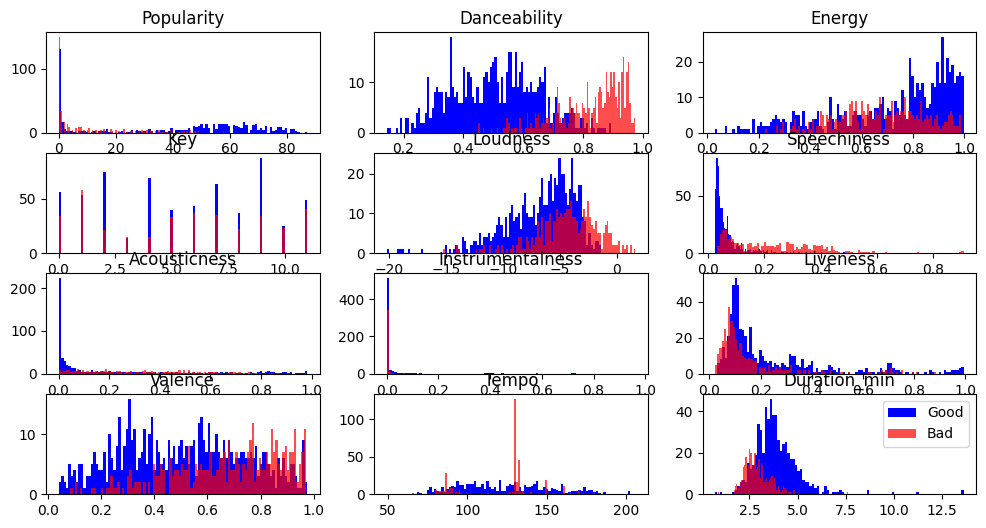

In [84]:
plot_hist_vs(X)

Plotting the distribution between each 25 different pairs of features (Plotando a distribuição entre cada 25 pares diferente das features).

Each time this code is run, it will plot different pairs, because there are more than 25 different pairs (Cada vez que esse código for executado, ele plotará pares diferentes, porque tem mais do que 25 pares diferentes).

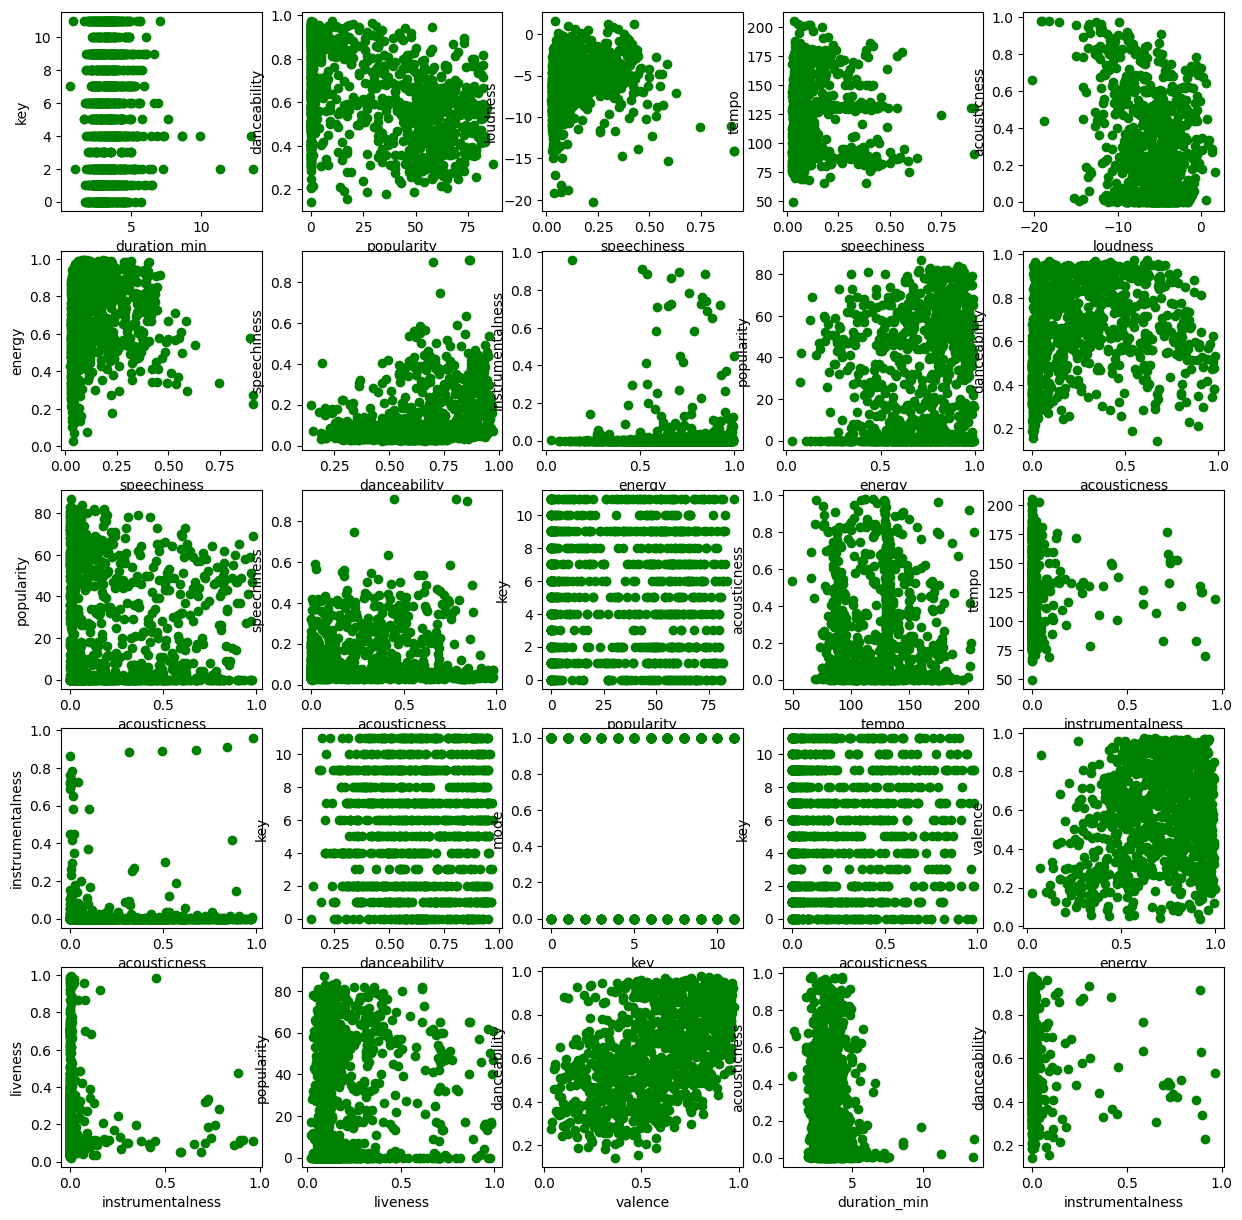

In [86]:
pairs = get_pairs(X_num)

fig, axs = plt.subplots(5, 5)
i = 0
for rows in axs:
    for ax in rows:
        ax.scatter(X_num[pairs[i][0]], X_num[pairs[i][1]], c='g')
        ax.set_xlabel(pairs[i][0])
        ax.set_ylabel(pairs[i][1])
        i+=1
plt.show()

Computing the correlation between each feature (Calculando a correlação entre cada feature).

In [88]:
X_corr = X_num.corr()
X_corr

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
popularity,1.000000,-0.384378,0.133587,0.012433,-0.146461,0.021448,-0.337709,-0.218468,0.015894,0.053100,-0.077873,-0.019295,0.221361
danceability,-0.384378,1.000000,-0.218017,-0.008203,0.196419,-0.010944,0.371626,0.251087,-0.110093,-0.240471,0.487388,-0.096490,-0.408243
energy,0.133587,-0.218017,1.000000,0.002421,0.607230,-0.119448,0.006405,-0.616818,0.007258,0.133774,0.176669,0.158513,0.095979
key,0.012433,-0.008203,0.002421,1.000000,-0.026120,-0.120825,-0.026196,0.013692,0.015681,0.026699,0.017331,-0.020200,-0.018467
loudness,-0.146461,0.196419,0.607230,-0.026120,1.000000,-0.124208,0.160003,-0.309100,-0.108615,-0.062711,0.201220,0.103914,-0.128506
mode,0.021448,-0.010944,-0.119448,-0.120825,-0.124208,1.000000,-0.004778,0.079664,0.054032,0.006375,-0.013359,0.027009,-0.082533
speechiness,-0.337709,0.371626,0.006405,-0.026196,0.160003,-0.004778,1.000000,0.147949,-0.082213,-0.021417,0.183768,-0.023927,-0.256856
acousticness,-0.218468,0.251087,-0.616818,0.013692,-0.309100,0.079664,0.147949,1.000000,-0.033782,0.015929,-0.078716,-0.096575,-0.165260
instrumentalness,0.015894,-0.110093,0.007258,0.015681,-0.108615,0.054032,-0.082213,-0.033782,1.000000,-0.011696,-0.068299,0.010875,0.074361
liveness,0.053100,-0.240471,0.133774,0.026699,-0.062711,0.006375,-0.021417,0.015929,-0.011696,1.000000,-0.172257,0.060445,0.166861


Applying a condition to view only correlations above a threshold and different from 1 (Aplicando uma condição para visualizar apenas as correlações acima de um threshold e diferente de 1).

In [90]:
mask = (abs(X_corr) > .4) & (abs(X_corr) != 1)
X_corr.where(mask).stack().sort_values(ascending=False)

energy        loudness        0.607230
loudness      energy          0.607230
valence       danceability    0.487388
danceability  valence         0.487388
duration_min  danceability   -0.408243
danceability  duration_min   -0.408243
energy        acousticness   -0.616818
acousticness  energy         -0.616818
dtype: float64

Plotting the heatmap with the correlation between all features (Plotando o heatmap com a correlação entre todas as features).

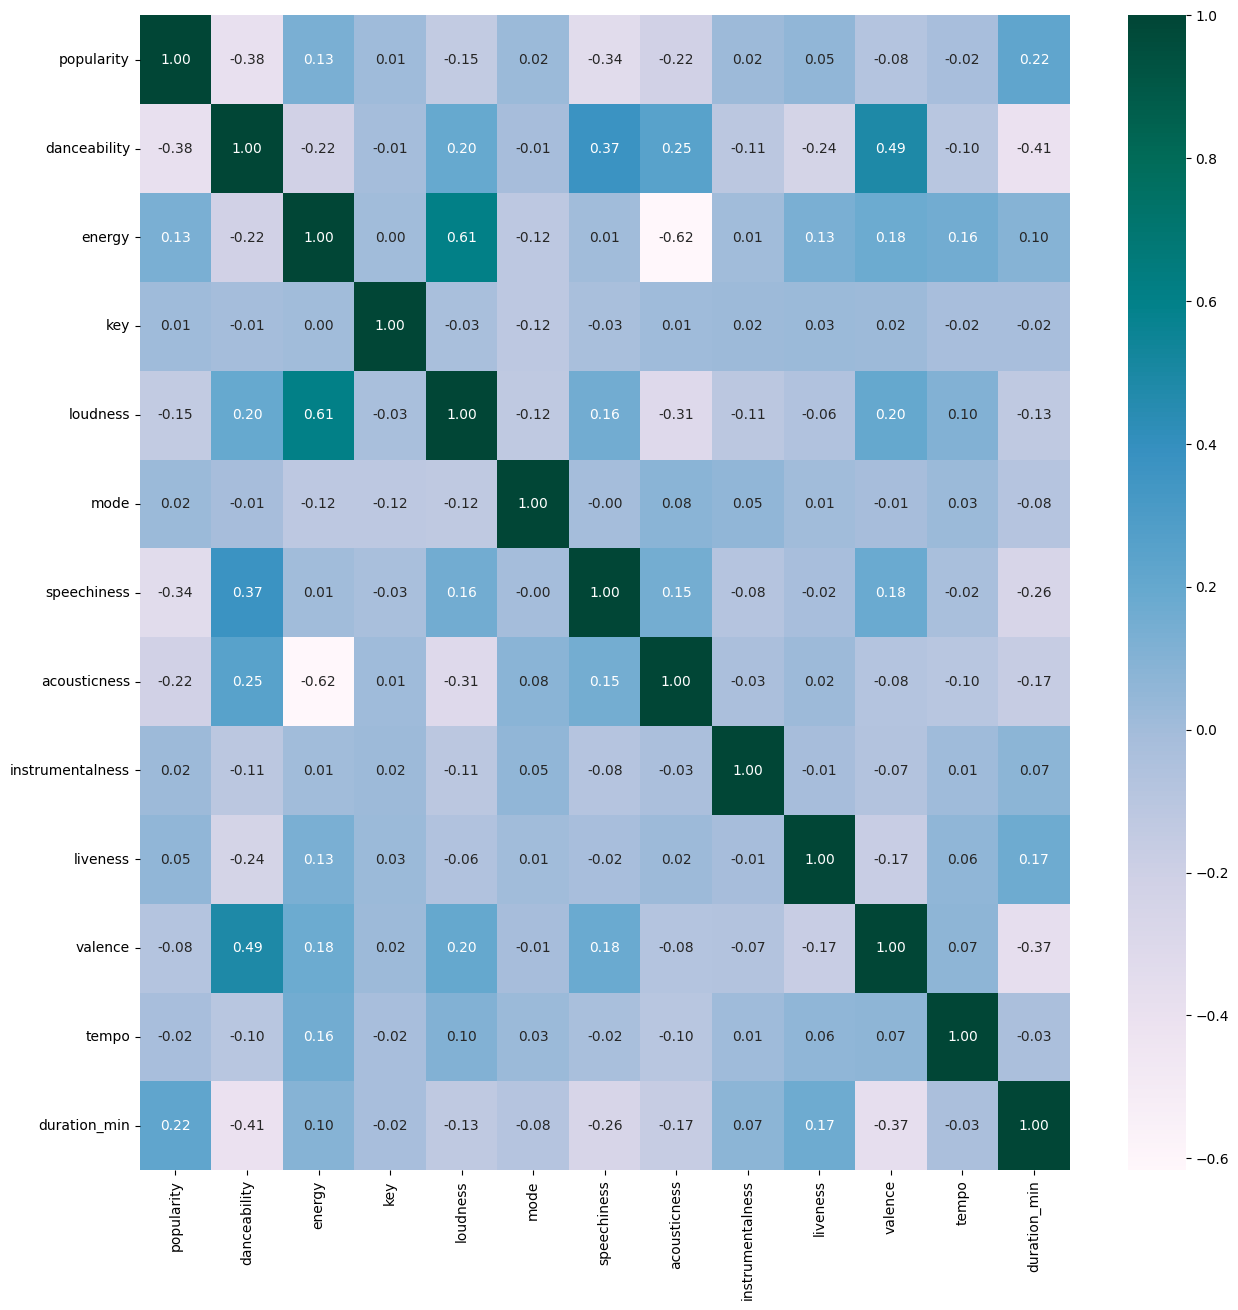

In [92]:
sns.heatmap(X_corr, annot=True, fmt='.2f', cmap='PuBuGn')
plt.show()

<a name="5.1"></a>
### PCA
**[EN-US]**

The PCA (Principal Component Analysis) algorithm is used for dimensionality reduction, to visualize high-dimensional vectors and matrices. It tries to combine the variances between the variables, capturing as much information as possible in the original examples. We find 1 or more principal components (new $Z$ axes), so that when measuring their data coordinates on the new axis, we still have very useful information.

Using the `exaplained_variance_ratio_` function, we query how much the principal components explain the variance in our data, whether or not projecting the data onto these axes helps to retain most of the variability or most of the information in the original dataset. The higher the explained variance, the more information the feature is capturing.

**[PT-BR]**

O algoritmo PCA (Principal Component Analysis) é utilizado para redução de dimensionalidade, para visualizar vetores e matrizes de alta dimensão. Ele tenta combinar as variâncias entre as variáveis, capturando o máximo de informação possível nos exemplos originais. Encontramos 1 ou mais principal components (novos eixos $Z$), para que, ao medir suas coordenadas de dados no novo eixo, ainda tenhamos informações muito úteis.

Utilizando a função `exaplained_variance_ratio_`, nós consultamos o quanto os principal components explicam a variância em nossos dados, se a projeção dos dados nesses eixos ajudam ou não a reter a maior parte da variabilidade ou a maioria das informações no dataset original. Quando maior a explained variance, mais informação a feature está capturando.

Applying z-score normalization to the dataset, so that it has a mean of 0 and a standard deviation of 1. To facilitate the computation of PCA (Aplicando a normalização z-score no dataset, para ele ter a média 0 e desvio padrão 1. Para facilitar o cálculo do PCA).
$$X = \frac{X - \mu}{\sigma^2}$$
* $\mu$: mean (média).
* $\sigma^2$: standard deviation (desvio-padrão).

We scale the dataset before applying PCA, because this makes it easier to calculate the algorithm (Escalamos o dataset antes de aplicar o PCA, porque assim, facilitamos o cálculo do algoritmo).

In [95]:
X_num_scaler = StandardScaler()
X_num_norm = X_num_scaler.fit_transform(X_num)

Applying PCA with only 2 principal components ($Z$ axes) to the dataset (Aplicando o PCA com apenas 2 principal components (eixos $Z$) ao dataset).

In [97]:
# Instantiating PCA with 2 principal components
# Instânciando o PCA com 2 principal components
pca = PCA(n_components=2)
# Fitting PCA to our original scaled dataset
# Ajustando o PCA ao nosso dataset original escalado
X_num_trans = pca.fit_transform(X_num_norm)
# Creating a dataframe with the matrix transformed into only 2 features
# Criando um dataframe com a matriz transformada em apenas 2 features
df_pca = pd.DataFrame(
    X_num_trans,
    columns=['principal_component_1', 'principal_component_2']
)
print(f'Explained variance: {pca.explained_variance_ratio_}')

df_pca.head()

Explained variance: [0.19376059 0.16727203]


,principal_component_1,principal_component_2
0,0.167824,0.065374
1,0.306928,-2.005225
2,0.540097,-0.196749
3,-0.793902,-1.978283
4,-0.623088,-2.372027


Plotting the dataset after PCA transformation (Plotando o dataset após a transformação do PCA).

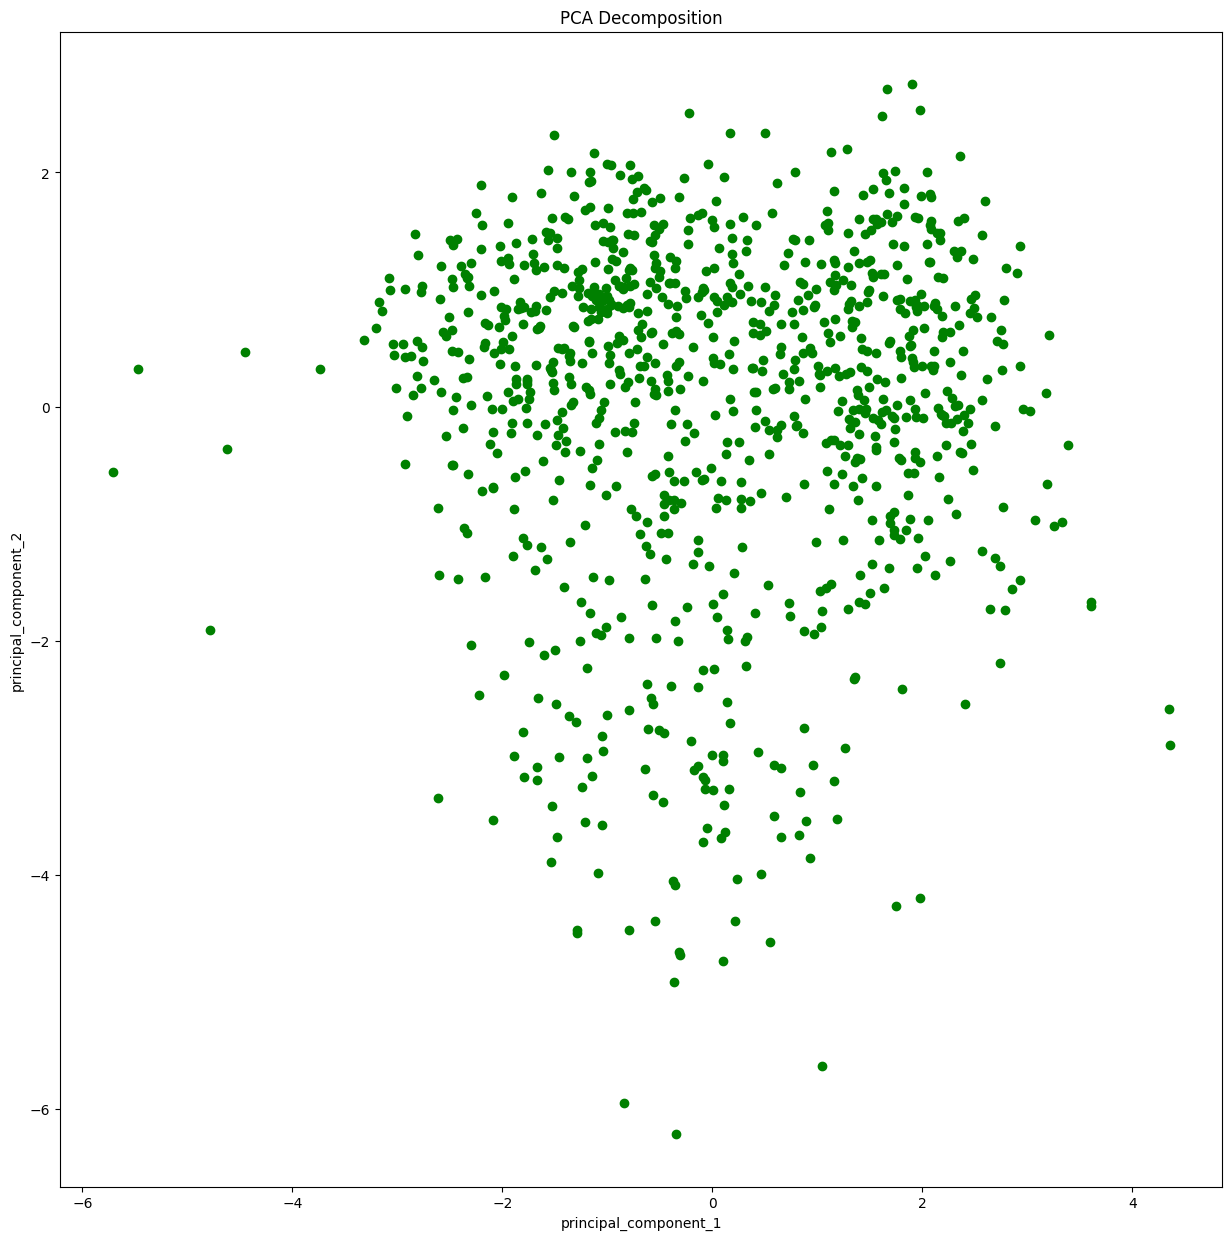

In [99]:
plt.scatter(df_pca['principal_component_1'], df_pca['principal_component_2'], color='g')
plt.xlabel('principal_component_1')
plt.ylabel('principal_component_2')
plt.title('PCA Decomposition')
plt.show()

<a name="6"></a>
## Preprocessing (Pré-processamento)
**[EN-US]**

In data preprocessing, the dataset will be divided into training, validation and test sets. Each of them will be scaled to have a mean of 0 and a standard deviation of 1, using the `z-score` method.

**[PT-BR]**

No pré-processamento dos dados, o dataset será dividido entre o set de treino, validação e teste. Cada um deles será escalado para ter média 0 e desvio-padrão 1, utilizando o método `z-score`.

Splitting the dataset between the training, validation and test sets (Dividindo o dataset entre o set de treino, validação e teste).

In [102]:
# Creating the column vector of the target label y to be divided along
# Criando o vetor de coluna do target label y para ser divido junto
y = X.iloc[:, -2].copy().to_numpy().reshape((-1, 1))

item_train, item_, y_train, y_ = train_test_split(X_num_oh, y, test_size=.4, shuffle=True, random_state=42)
user_train, user_ = train_test_split(user_df, test_size=.4, shuffle=True, random_state=42)
print(f'item_train.shape: {item_train.shape}\ny_train.shape: {y_train.shape}\n')
print(f'user_train.shape: {user_train.shape}\n')

item_cv, item_test, y_cv, y_test = train_test_split(item_, y_, test_size=.5, shuffle=True, random_state=42)
user_cv, user_test = train_test_split(user_, test_size=.5, shuffle=True, random_state=42)
print(f'item_cv.shape: {item_cv.shape}, item_test.shape: {item_test.shape}\ny_cv.shape: {y_cv.shape}, y_test.shape: {y_test.shape}\n')
print(f'user_cv.shape: {user_cv.shape}, user_test.shape: {user_test.shape}')

item_train.shape: (589, 23)
y_train.shape: (589, 1)

user_train.shape: (589, 13)

item_cv.shape: (196, 23), item_test.shape: (197, 23)
y_cv.shape: (196, 1), y_test.shape: (197, 1)

user_cv.shape: (196, 13), user_test.shape: (197, 13)


Applying z-score normalization to each dataset, so that they have a mean of 0 and a standard deviation of 1 (Aplicando a normalização z-score em cada dataset, para eles terem média 0 e desvio padrão 1).
$$X = \frac{X - \mu}{\sigma^2}$$
* $\mu$: mean (média).
* $\sigma^2$: standard deviation (desvio-padrão).

In [104]:
item_scaler = StandardScaler()
user_scaler = StandardScaler()

item_train_norm = item_scaler.fit_transform(item_train)
user_train_norm = user_scaler.fit_transform(user_train)

item_cv_norm = item_scaler.transform(item_cv)
user_cv_norm = user_scaler.transform(user_cv)

item_test_norm = item_scaler.transform(item_test)
user_test_norm = user_scaler.transform(user_test)

Defining the number of features for the user and item neural network (Definindo o número de features para a rede neural do usuário e do item).

In [106]:
num_user_features, num_item_features = user_df.shape[1], X_num_oh.shape[1]
print(f'num_user_features: {num_user_features}\nnum_item_features: {num_item_features}')

num_user_features: 13
num_item_features: 23


<a name="7"></a>
## Model
**[EN-US]**

The model used for the recommendation system was the `Content-Based Filtering` algorithm.

**[EN-US]**

O modelo utilizado para o sistema de recomendação foi o algoritmo `Content-Based Filtering`.

<a name="7.1"></a>
### Content-Based Filtering Algorithm
<img align='center' src='./images/content-based-filtering.png' style='width:400px;'>

**[EN-US]**

The Content-Based Filtering algorithm is a recommendation algorithm that recommends items to the user based on the user's features and the items' features to find a good match by calculating the vectors $\vec{v}_u$ for the user and the vectors $\vec{v}_r$ for the items. The feature vectors $x$ for the users and items can have different sizes, but the vectors $\vec{v}$ for the users and items must have the same size.
* $v_u^{(j)}$: represents a vector of the user's preferences, calculated from the features $x_u^{(j)}$ for user $j$.
* $v_r^{(i)}$: vector of numbers calculated for the item, from the features $x_r^{(i)}$ for item $i$.

With an appropriate choice of these vectors, we expect that the sigmoid function $g$ applied to the dot product between them will be a good predictor of the rating given by user $j$ for item $i$.
$$g(v_u^{(j)} . v_r^{(i)})$$

**[PT-BR]**

O algoritmo Content-Based Filtering, é um algoritmo de recomendação, que recomenda itens ao usuário, usando como base as características do usuário e as características dos itens, para encontrar uma boa combinação, calculando os vetores $\vec{v}_u$ para o usuário e os vetores $\vec{v}_r$ para os itens. Os vetores de features $x$ para os usuários e para os itens podem ter tamanhos diferentes, mas os vetores $\vec{v}$ para os usuários e para os itens devem ter o mesmo tamanho.
* $v_u^{(j)}$: representa um vetor das preferências do usuário, calculados a partir das features $x_u^{(j)}$ para o usuário $j$.
* $v_r^{(i)}$: vetor de número calculados para o item, a partir das features $x_r^{(i)}$ para o item $i$.

Com uma escolha apropriada desse vetores, esperamos que a função sigmoide $g$ aplicada ao dot product entre eles seja uma boa previsão da classificação dada pelo usuário $j$ para item $i$.
$$g(v_u^{(j)} . v_r^{(i)})$$

<a name="7.2"></a>
### Content-Based Filtering Model
**[EN-US]**

To compute the vector $\vec{v}$ given the vector $x$ we need to create a neural network. For the vector $\vec{v}_u$ we will call it **User Network** and for the vector $\vec{v}_r$ we will call it **Item Network**.
* **`User Network`**: receives as input a vector of features of the user $x_u$ and the output layer is not a layer with a single neuron but rather with more, which ends up generating the output $\vec{v}_u$, which is the vector that describes the user.
* **`Item Network`**: receives as input a vector of features of the item $x_r$ and the output layer is not a layer with a single neuron but rather with more, which ends up generating the output $\vec{v}_r$, which is the vector that describes the item.

The user network and the item network can, hypothetically, have different numbers of hidden layers and neurons per hidden layer, only the output layer should have the same dimension between the 2 vectors. We take the user and item neural networks and join the two, then take the inner product of the outputs of both neural networks, and calculate the sigmoid function of the output of this inner product.
$$g(v_u^{(j)} . v_r^{(i)})$$
Cost function to adjust all parameters of the neural networks, applying Frobenius norm regularization to encourage the neural networks to keep their parameter values small:
$$\begin{align*}
& J(W, b) = \frac{1}{m} \sum\limits_{(i j): r(i j)=1}^m \mathcal{L}(g(v_u^{(j)} . v_r^{(i)}), y^{(i j)}) + \frac{\lambda}{2m} ||w||^2_F \\
& = \frac{1}{m} \sum\limits_{(i j): r(i j)=1}^m [y^{(i j)} \log{g(v_u^{(j)} . v_r^{(i)})} + (1 - y^{(i j)}) \log{1 - g(v_u^{(j)} . v_r^{(i)})}] + \frac{\lambda}{2m} \sum\limits_{l = 1}^L ||W^{[l]}||^2_F
\end{align*}$$

**[PT-BR]**

Para computar o vetor $\vec{v}$ dado o vetor $x$ precisamos criar uma rede neural. Para o vetor $\vec{v}_u$ chamaremos de **Rede do Usuário** e para o vetor $\vec{v}_r$ chamaremos de **Rede do Item**.
* **`Rede do Usuário`**: recebe como input um vetor de features do usuário $x_u$ e a output layer não é uma layer com um único neurônio e sim com mais, que acaba gerando o output $\vec{v}_u$, que é o vetor que descreve o usuário.
* **`Rede do Item`**: recebe como input um vetor de features do item $x_r$ e a output layer não é uma layer com um único neurônio e sim com mais, que acaba gerando o output $\vec{v}_r$, que é o vetor que descreve o item.

A user network e a item network, podem, hipoteticamente, ter números diferentes de hidden layers e de neurônios por hidden layers, apenas a output layer deverá ter a mesma dimenção entre os 2 vetores. Pegamos a rede neural de usuários e de itens e juntamos as duas e, em seguida, pegamos o inner product dos outputs de ambas as redes neurais, e calculamos a função sigmoide do output desse inner product.
$$g(v_u^{(j)} . v_r^{(i)})$$
Cost function para ajustar todos os parâmetros das redes neurais, aplicando a regularização da norma Frobenius para incentivar as redes neurais a manter os valores de seus parâmetros pequenos:
$$\begin{align*}
& J(W, b) = \frac{1}{m} \sum\limits_{(i j): r(i j)=1}^m \mathcal{L}(g(v_u^{(j)} . v_r^{(i)}), y^{(i j)}) + \frac{\lambda}{2m} ||w||^2_F \\
& = \frac{1}{m} \sum\limits_{(i j): r(i j)=1}^m [y^{(i j)} \log{g(v_u^{(j)} . v_r^{(i)})} + (1 - y^{(i j)}) \log{1 - g(v_u^{(j)} . v_r^{(i)})}] + \frac{\lambda}{2m} \sum\limits_{l = 1}^L ||W^{[l]}||^2_F
\end{align*}$$

Setting the model (Definindo o modelo).

In [111]:
LAMBDA = 1e-3
LR = 1e-4
OPT = Adam(learning_rate=LR)
LOSS = BinaryCrossentropy()

model = model_compile(OPT, LOSS, num_user_features, num_item_features)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 13)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 23)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_NN (Sequential)          │ (None, 32)                │          47,958 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ item_NN (Sequential)          │ (None, 32)                │          50,518 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ l2__norm (L2_Norm)            │ (None, 32)                │               0 │ user_NN[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ l2__norm_1 (L2_Norm)          │ (None, 32)                │               0 │ item_NN[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dot (Dot)                     │ (None, 1)                 │               0 │ l2__norm[0][0],            │
│                               │                           │                 │ l2__norm_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sigmoid (Sigmoid)             │ (None, 1)                 │               0 │ dot[0][0]                  │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 98,476 (384.67 KB)

 Trainable params: 96,692 (377.70 KB)

 Non-trainable params: 1,784 (6.97 KB)

Fitting the model (Treinando o modelo).

In [113]:
history = model.fit([user_train_norm, item_train_norm], y_train, epochs=1000, verbose=2)

Epoch 1/1000
19/19 - 5s - 266ms/step - auc: 0.6670 - loss: 1.2349
Epoch 2/1000
19/19 - 0s - 4ms/step - auc: 0.8741 - loss: 1.1702
Epoch 3/1000
19/19 - 0s - 4ms/step - auc: 0.9397 - loss: 1.1169
Epoch 4/1000
19/19 - 0s - 4ms/step - auc: 0.9622 - loss: 1.0719
Epoch 5/1000
19/19 - 0s - 4ms/step - auc: 0.9732 - loss: 1.0372
Epoch 6/1000
19/19 - 0s - 3ms/step - auc: 0.9769 - loss: 1.0060
Epoch 7/1000
19/19 - 0s - 3ms/step - auc: 0.9800 - loss: 0.9795
Epoch 8/1000
19/19 - 0s - 3ms/step - auc: 0.9870 - loss: 0.9475
Epoch 9/1000
19/19 - 0s - 3ms/step - auc: 0.9888 - loss: 0.9266
Epoch 10/1000
19/19 - 0s - 3ms/step - auc: 0.9906 - loss: 0.9019
Epoch 11/1000
19/19 - 0s - 4ms/step - auc: 0.9896 - loss: 0.8878
Epoch 12/1000
19/19 - 0s - 3ms/step - auc: 0.9916 - loss: 0.8744
Epoch 13/1000
19/19 - 0s - 3ms/step - auc: 0.9929 - loss: 0.8488
Epoch 14/1000
19/19 - 0s - 4ms/step - auc: 0.9930 - loss: 0.8366
Epoch 15/1000
19/19 - 0s - 4ms/step - auc: 0.9939 - loss: 0.8196
Epoch 16/1000
19/19 - 0s - 4ms/s

Plotting the error and metric during model training (Plotando o erro e a métrica durante o treinamento do modelo).

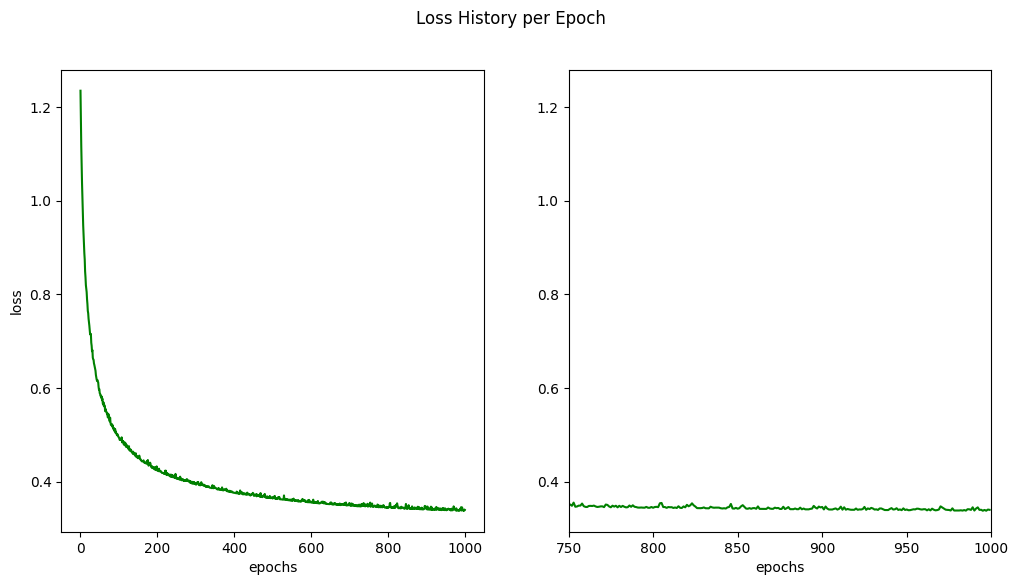

In [115]:
plot_loss(history)

Evaluating the model on training and validation data (Avaliando o modelo nos dados de treino e de validação).

In [117]:
train_eval = model.evaluate([user_train_norm, item_train_norm], y_train, verbose=0)
cv_eval = model.evaluate([user_cv_norm, item_cv_norm], y_cv, verbose=0)

print(f'Train set evaluation: {train_eval[0]:.2f}\nValidation set evaluation: {cv_eval[0]:.2f}')

Train set evaluation: 0.34
Validation set evaluation: 0.39


<a name="8"></a>
## Prediction (Previsão)
**[EN-US]**

Calculating the model's prediction on the training, validation and test data, because this is already the final model.

**[PT-BR]**

Calculando a previsão do modelo sobre os dados de treino, de validação e de teste, porque este já é o modelo final.

<a name="8.1"></a>
### Prediction with Model Only (Previsão apenas com o Modelo)
**[EN-US]**

Using only the trained model to calculate the prediction on the training and validation data.

**[PT-BR]**

Utilizando apenas o modelo treinado para calcular a previsão sobre os dados de treino e de validação.

Performing prediction on training data (Realizando a previsão sobre os dados de treino).

In [121]:
y_hat_train = model.predict([user_train_norm, item_train_norm], verbose=0)
y_hat_train[:10]

array([[0.2690234 ],
       [0.2692214 ],
       [0.7309827 ],
       [0.73097867],
       [0.26905254],
       [0.73078036],
       [0.73098356],
       [0.7306904 ],
       [0.7309272 ],
       [0.2690392 ]], dtype=float32)

Plotting the top $m$ recommendations on the training data (Plotando as $m$ primeiras recomendações sobre os dados de treino).

In [123]:
m = 10

# Sorting the vector with the predictions in descending order and selecting only the indexes
# Ordenando o vetor com as previsões em ordem decrescente e selecionando apenas os índices
sorted_idx_train = np.argsort(-y_hat_train, axis=0).squeeze().tolist()
# Slicing only the indices present in the training dataset in the complete dataset
# Selecionando apenas os índices presentes no dataset de treino no dataset completo
items_train = items.iloc[item_train.index].reset_index().drop(columns=['index']).copy()
# Slicing the recommended indexes in the training items dataset, to sort it in the same order
# Selecionando os índices recomendados no dataset de items de treino, para ordená-lo na mesma ordem
sorted_items_train = items_train.iloc[sorted_idx_train].reset_index().drop(columns=['index']).copy()
# Plotting the top m recommended items
# Plotando os top m items recomendados
sorted_items_train.head(m)

,name,artists
0,Days Go By,The Offspring
1,"The Pretender - Live at Studio 606 West, North...",Foo Fighters
2,Riptide - Live From London,Gossling
3,Everyday I Love You Less and Less,Kaiser Chiefs
4,Down,311
5,Santa Monica,Everclear
6,Aerials,System Of A Down
7,May 16,Lagwagon
8,I-E-A-I-A-I-O,System Of A Down
9,Crazy - James Michael Mix,Alanis Morissette


Performing prediction on the validation data (Realizando a previsão sobre os dados de validação).

In [125]:
y_hat_cv = model.predict([user_cv_norm, item_cv_norm], verbose=0)
y_hat_cv[:10]

array([[0.26985765],
       [0.26946977],
       [0.730879  ],
       [0.7306311 ],
       [0.73093367],
       [0.7309843 ],
       [0.7310142 ],
       [0.7310005 ],
       [0.26903996],
       [0.73086953]], dtype=float32)

Plotting the top $m$ recommendations on the validation data (Plotando as $m$ primeiras recomendações sobre os dados de validação).

In [127]:
m = 10

# Sorting the vector with the predictions in descending order and selecting only the indexes
# Ordenando o vetor com as previsões em ordem decrescente e selecionando apenas os índices
sorted_idx_cv = np.argsort(-y_hat_cv, axis=0).squeeze().tolist()
# Slicing only the indices present in the training dataset in the complete dataset
# Selecionando apenas os índices presentes no dataset de treino no dataset completo
items_cv = items.iloc[item_cv.index].reset_index().drop(columns=['index']).copy()
# Slicing the recommended indexes in the training items dataset, to sort it in the same order
# Selecionando os índices recomendados no dataset de items de treino, para ordená-lo na mesma ordem
sorted_items_cv = items_cv.iloc[sorted_idx_cv].reset_index().drop(columns=['index']).copy()
# Plotting the top m recommended items
# Plotando os top m items recomendados
sorted_items_cv.head(m)

,name,artists
0,Father Of Mine,Everclear
1,The Kids Aren't Alright,The Offspring
2,Walk On Water,Thirty Seconds To Mars
3,Sex & Candy,Marcy Playground
4,Celebrity Skin,Hole
5,Streetcar,Funeral For A Friend
6,Can I Play with Madness - 1998 Remaster,Iron Maiden
7,Head over Feet - 2015 Remaster,Alanis Morissette
8,Rude,MAGIC!
9,Good,Better Than Ezra


<a name="8.2"></a>
### Cosine Similarity Prediction (Previsão com a Similaridade de Cosseno)
**[EN-US]**

The neural network computes 2 feature vectors, the user's feature vector $\vec{v}_u$ and the item's feature vector $\vec{v}_r$. Therefore, similar items will have similar vectors $\vec{v}$, so this information can be used to make recommendations.

We can use cosine similarity to find items similar to item $i$. Cosine similarity is a similarity metric. It uses the cosine of the angle between 2 vectors. Based on this, it tells whether 2 vectors are close or not by calculating the cosine of their internal angle. The measure of cosine similarity between vectors $v_r^{(k)}$ and $v_r^{(i)}$:
$$\cos{\beta} = \frac{v_r^{(k)} . v_r^{(i)}}{||v_r^{(k)}|| \times ||v_r^{(i)}||}$$
Where:
* $v_r^{(k)} . v_r^{(i)}$: dot product between 2 vectors.
* $||v_r^{(i)}||$: norm or magnitude of the vector $v_r^{(i)}$.

**[PT-BR]**

A rede neural calcula 2 vetores de features, o vetor de features do usuário $\vec{v}_u$ e o vetor de features do item $\vec{v}_r$. Portanto, itens similares terão vetores $\vec{v}$ similares, então, essa informação pode ser usada para fazer recomendações.

Podemos utilizar a similaridade de cosseno para encontrar itens similares ao item $i$. A similaridade de cosseno é uma métrica de similaridade. Ela faz o uso do cosseno do ângulo entre 2 vetores. Com base nisso, ela informa se 2 vetores estão próximos ou não calculando o cosseno de seu ângulo interno. A medida da similaridade de cosseno entre os vector $v_r^{(k)}$ e $v_r^{(i)}$:
$$\cos{\beta} = \frac{v_r^{(k)} . v_r^{(i)}}{||v_r^{(k)}|| \times ||v_r^{(i)}||}$$
Onde:
* $v_r^{(k)} . v_r^{(i)}$: dot product entre 2 vetores.
* $||v_r^{(i)}||$: norma ou magnitude do vetor $v_r^{(i)}$.

Setting the model using only the item neural network (Definindo o modelo usando apenas a rede neural do item).

In [130]:
LOSS_ITEM = MeanSquaredError()

model_item = model_compile(OPT, LOSS_ITEM, num_user_features, num_item_features, item_similarity=True)
model_item.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 23)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ item_NN (Sequential)                 │ (None, 32)                  │          50,518 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ l2__norm_3 (L2_Norm)                 │ (None, 32)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243,904 (952.75 KB)

 Trainable params: 49,626 (193.85 KB)

 Non-trainable params: 892 (3.48 KB)

 Optimizer params: 193,386 (755.42 KB)

Collecting the item network weights from the pre-trained complete neural network and setting them in the new network (Coletando os pesos da rede do item, da rede neural completa pré-treinada e definindo na nova rede).

In [132]:
item_nn_weights = model.get_layer('item_NN').get_weights()
model_item.get_layer('item_NN').set_weights(item_nn_weights)

Scaling the complete item matrix and calculating the feature vector of all items (Escalando a matriz de itens completa e calculando o vetor de features de todos os itens).

In [134]:
item_norm = item_scaler.transform(X_num_oh)

item_feature_vectors = model_item.predict(item_norm, verbose=0)
print(f'Size of all predicted item feature vectors: {item_feature_vectors.shape}')

Size of all predicted item feature vectors: (982, 32)


Computing cosine similarity for all items (Calculando a similaridade de cosseno para todos os itens).

In [138]:
dim = item_feature_vectors.shape[0]
cos_sim = np.zeros((dim, dim))

for i in range(dim):
    for j in range(dim):
        cos_sim[i, j] = cosine_similarity(
            item_feature_vectors[i, :].reshape(1, -1),
            item_feature_vectors[j, :].reshape(1, -1)
        )

m_cos_sim = np.ma.masked_array(cos_sim, mask=np.identity(dim))

features = ['name_root', 'artists_root', 'name_recommended', 'artists_recommended']
data = []
for i in range(dim):
    min_idx = np.argmax(m_cos_sim[i])
    example = [
        items.loc[i, 'name'],
        items.loc[i, 'artists'],
        items.loc[min_idx, 'name'],
        items.loc[min_idx, 'artists']
    ]
    data.append(example)

cos_sim_rec = pd.DataFrame(data, columns=features)

In [139]:
m = 20
cos_sim_rec.head(m)

,name_root,artists_root,name_recommended,artists_recommended
0,Cheia de Manias,Raça Negra,Out With The Old (uncensored Sterilized) (feat...,Alleylife
1,Que Se Chama Amor,Só Pra Contrariar,Creep,Kina Grannis
2,Paparico,Molejo,"Naive - Live At Abbey Road Studios,United King...",The Kooks
3,Telegrama,Exaltasamba,Borbulhas de Amor (Tenho um Coração) [Borbujas...,Fagner
4,É Tarde Demais,Raça Negra,O último romântico,Lulu Santos
5,Pimpolho,Art Popular,Sex & Candy,Marcy Playground
6,Cilada,Molejo,Paparico,Molejo
7,Rude,MAGIC!,Father Of Mine,Everclear
8,"Feels (feat. Pharrell Williams, Katy Perry & B...",Calvin Harris,Beggin',Måneskin
9,Havana (feat. Young Thug),Camila Cabello,Cegos do castelo,Nando Reis


In [140]:
dim = item_feature_vectors.shape[0]
# dim - 1 because we will discard similarity between the same items
# dim - 1 porque descartaremos a similaridade entre os mesmos itens
cos_sim = np.zeros((dim, dim - 1))
# List to store each example
# Lista para armazenar cada exemplo
data = []

# Looping through all items and calculating the cosine similarity between each different item
# Percorrendo todos os itens e calculando a similaridade de cosseno entre cada item diferente
for i in range(dim):
    for j in range(dim):
        # We will calculate similarity only if they are different items
        # Calcularemos a similaridade apenas se forem items diferentes
        if i != j:
            cos_sim[i, j - 1] = cosine_similarity(
                item_feature_vectors[i, :].reshape(1, -1),
                item_feature_vectors[j, :].reshape(1, -1)
            )
    # Selecting the index of the most similar vector
    # Selecionando o índice do vetor mais similar
    min_idx = np.argmax(cos_sim[i])
    example = [
        items.loc[i, 'name'],
        items.loc[i, 'artists'],
        items.loc[min_idx, 'name'],
        items.loc[min_idx, 'artists']
    ]
    data.append(example)

# Creating the dataframe with the items and their most similar items
# Criando o dataframe com os itens e seus itens mais similares
features = ['name_root', 'artists_root', 'name_recommended', 'artists_recommended']
cos_sim_rec_2 = pd.DataFrame(data, columns=features)

In [141]:
# Number of items to display
# Número de itens a serem exibidos
m = 20
cos_sim_rec_2.head(m)

,name_root,artists_root,name_recommended,artists_recommended
0,Cheia de Manias,Raça Negra,Heavy Metal Winner,Consumed
1,Que Se Chama Amor,Só Pra Contrariar,Use Somebody - Acoustic Version,Isabella Celander
2,Paparico,Molejo,Chandelier,Kina Grannis
3,Telegrama,Exaltasamba,Vícios E Virtudes - Ao Vivo,Charlie Brown Jr.
4,É Tarde Demais,Raça Negra,Mulher de fases,Raimundos
5,Pimpolho,Art Popular,Karma Police,Radiohead
6,Cilada,Molejo,Que Se Chama Amor,Só Pra Contrariar
7,Rude,MAGIC!,Swallowed - Remastered,Bush
8,"Feels (feat. Pharrell Williams, Katy Perry & B...",Calvin Harris,Vengo dalla luna,Måneskin
9,Havana (feat. Young Thug),Camila Cabello,Meu Erro,Os Paralamas Do Sucesso


Plotting vectors with PCA (Plotando os vetores com PCA).

Explained variance: [0.99369574 0.0015811 ]


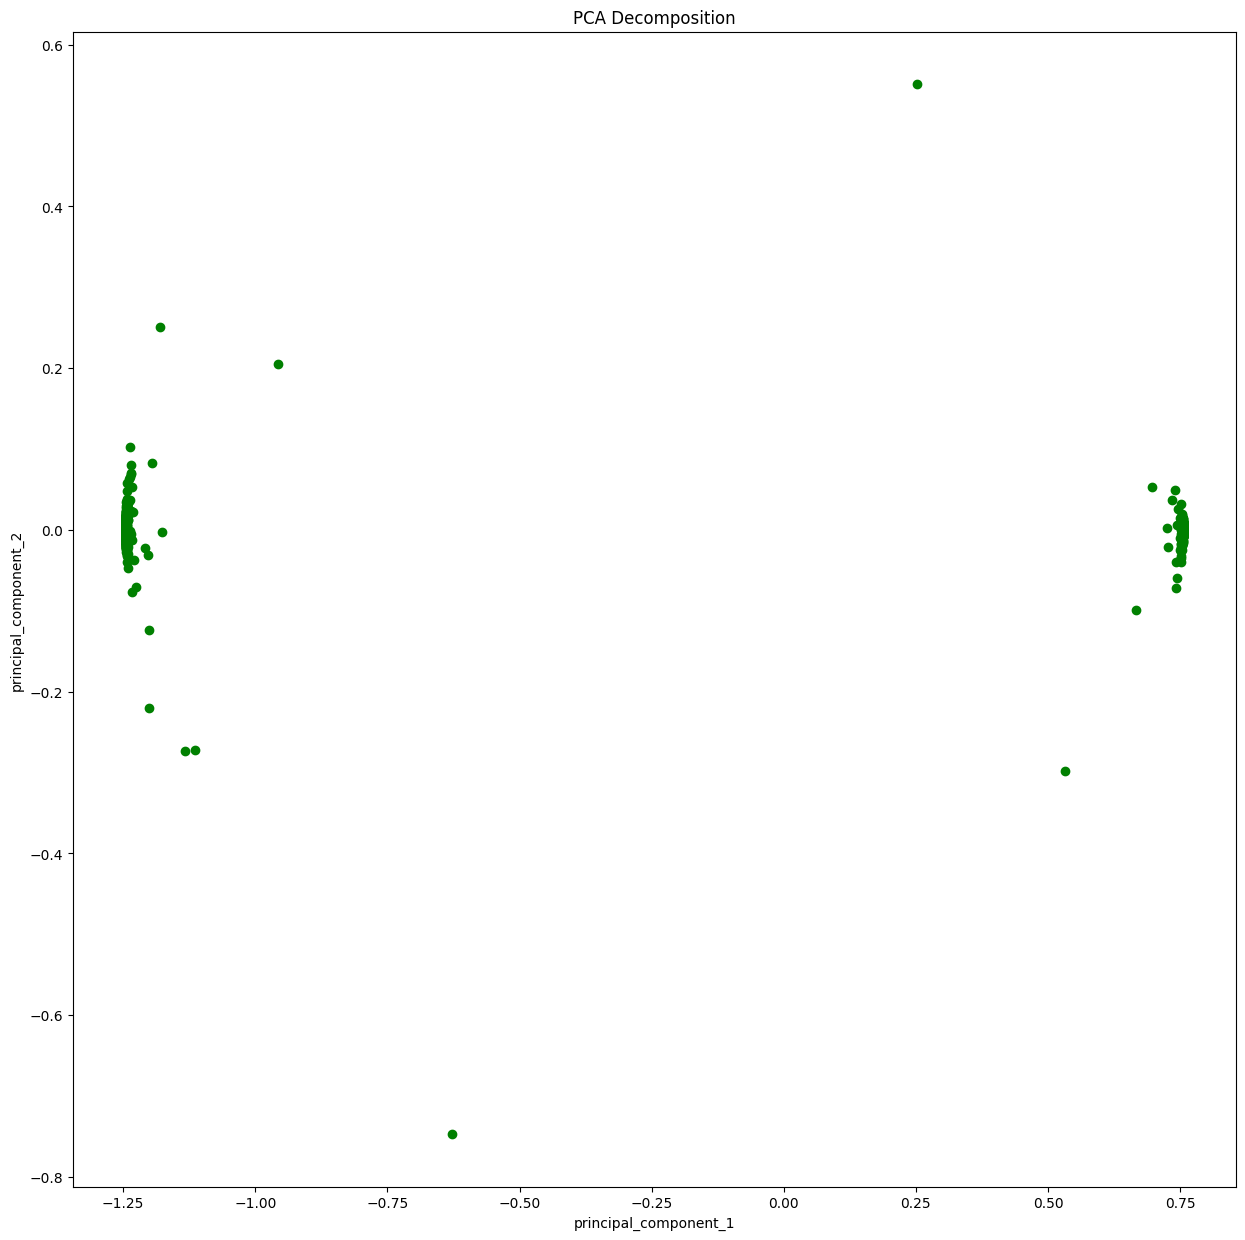

In [143]:
# Instantiating PCA with 2 principal components
# Instânciando o PCA com 2 principal components
pca_cos = PCA(n_components=2)
# Fitting PCA to our original scaled dataset
# Ajustando o PCA ao nosso dataset original escalado
item_trans = pca_cos.fit_transform(item_feature_vectors)
# Creating a dataframe with the matrix transformed into only 2 features
# Criando um dataframe com a matriz transformada em apenas 2 features
df_item_pca = pd.DataFrame(
    item_trans,
    columns=['principal_component_1', 'principal_component_2']
)
print(f'Explained variance: {pca_cos.explained_variance_ratio_}')

# Plotting principal components (Plotando os principal components)
plt.scatter(df_item_pca['principal_component_1'], df_item_pca['principal_component_2'], color='g')
plt.xlabel('principal_component_1')
plt.ylabel('principal_component_2')
plt.title('PCA Decomposition')
plt.show()